<a href="https://colab.research.google.com/github/WPozz/Calories-and-Wellbeing/blob/main/Gruppo11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 11: Clinical Text Classification**

# **Abstract (600 words)**

- Description of the original project
- Limitations of the original project
- Objective
- Method
- Results

## **1. Libraries installaton and import**

In [ ]:
# Installing libraries:

!pip install nlpaug transformers torch --upgrade --quiet
!pip install torch torchvision torchaudio transformers nlpaug --upgrade --quiet
print('Libary installed succesfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90

In [ ]:
# Basic libraries:

import os
import time
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import string
import re
import math
import copy

# Plot libraries:
import matplotlib.pyplot as plt
import seaborn as sns


# Sklearn:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, confusion_matrix, f1_score, balanced_accuracy_score, matthews_corrcoef, top_k_accuracy_score
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight

# Colab:
from google.colab import files
from google.colab import drive

# Torch and Transformers:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup, AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch.nn as nn
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F

# Data agumentation libraries:
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
from transformers import pipeline


# First way to upload the data (Dowload from Kaggle):
#import kagglehub
#path = kagglehub.dataset_download("shoubhikchakra/mtsamples-dataset")


print('Libraries succesfully imported')


Libraries succesfully imported


## **2. Data Loading**

In [ ]:


# Data loading:

# drive.mount('/content/gdrive')
# %cd '/content/gdrive/My Drive/DL'

try:
    raw_data = pd.read_csv('mtsamples.csv')
    print("Data succesfully loaded")
except FileNotFoundError:
    print(f"Error: data file not found.")

# Print basic info
print("Initial Data Info:")
print(raw_data.columns)
raw_data.head(5)

Data succesfully loaded
Initial Data Info:
Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


## **3. Data Pre-processing**

### **Pre Pre-processing plot functions**

Before going for the pre-processing it is important to plot the data and try to decide which are the changes needed for a good overall performance of the methods.

Here we define the functions with the plots for the EDA. The major plots are:
1. Label (class) distribution
2. Top k N-grams in the dataset
3. Top k N-grams for each label  

In [ ]:

# Barplot with label:

def plot_label_distribution(raw_data, column, title, filename):

    """
    Helper function to create and save a bar plot of a column's distribution.

    Inputs:
            raw_data = (list) data to analyze
            column   = (string) column to analyze
            title    = (string) title of the plot
            filename = (string)
    Output:
            none (just the plot)

    """
    print(f"Generating plot: {title}...")
    plt.figure(figsize=(10, 12))

    # Plotting
    sns.countplot(
        y=column,
        data=raw_data,
        order=raw_data[column].value_counts().index,
        palette='viridis'   # we can select another palette
    )

    # Formatting
    plt.title(title, fontsize=16)
    plt.xlabel('Number of Samples', fontsize=12)
    plt.ylabel('Medical Specialty', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show


# N-grams in the whole dataset:

def plot_top_ngrams(text_data,n,top_k,title):
    """
    This function creates and saves a bar plot
    for the top N-grams :

    Inputs:
            text_data = the actual data
            n = (scalar) number of grams to consider
            top_k = (scalar) how many elements to show
            title = (string) title of the plot
    Output:
            None (just the plot)

    """
    print(f"Generating plot: {title}...")


    # We remove the "stop words" and look for n-grams with (n x n) dimension

    vec = CountVectorizer(
         stop_words='english',
         ngram_range=(n, n)
     )


    X = vec.fit_transform(text_data)

    # We sum the counts for each n-gram across
    counts = X.sum(axis=0)

    # Get the names of the features, the n-grams and the counts
    words = vec.get_feature_names_out()

    # Create a df with n-grams and their counts
    counts_df = pd.DataFrame({
    'ngram': words,
    'count': np.asarray(counts).flatten() # Convert the row of the matrix into a dense array
     })

    # We only keep the top_k
    top_counts_df = counts_df.sort_values(by='count', ascending=False).head(top_k)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(
         x='count',
         y='ngram',
        data=top_counts_df,
        palette='viridis_r' # reversed palette
         )
    plt.title(title, fontsize=16)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('N-Gram', fontsize=12)
    plt.tight_layout()
    plt.show()


# Sentence lenght:

def plot_lenghts(text_data):
    """
    This function retrives and plots the average lenght of the sentences.

    Inputs:
            text_data = (list) data to analyze

    Outputs:
            None (just the plot)

    """
    sentence_lengths = [len(sentence.split()) for sentence in text_data]

    plt.figure(figsize=(10, 6))
    sns.histplot(sentence_lengths, bins='auto', kde=True, color='green', shrink= 1)
    plt.title('Distribution of Sentence Lengths')
    plt.xlabel('Sentence Length (words)')
    plt.ylabel('Frequency')
    plt.show()

    print(f"Average sentence length: {np.mean(sentence_lengths):.2f} words")
    print(f"Median sentence length: {np.median(sentence_lengths)} words")
    print(f"Max sentence length: {np.max(sentence_lengths)} words")
    print(f"Min sentence length: {np.min(sentence_lengths)} words")



# N-grams per class

def plot_ngrams_per_class(data, text_col, class_col, top_k=15, n=1, num_classes=6):
    """
    Plots a grid of bar charts showing the top N-grams for the
    top N most frequent classes.

    Inputs:
            data = (dataframe) data to analyze
            text_col = (string) name of the text column
            class_col = (string) name of the class column
            top_k =  (scalar) how many grams to show
            n = (scalar) number of grams to consider
            num_classes = (scalar) Number of classes to show

    Outputs:
            None (just the plots)
    """
    print(f"Generating plot: Top {n}-grams per Class (Top {num_classes})...")
    data_clean = data.dropna(subset=[text_col, class_col])
    top_classes = data_clean[class_col].value_counts().nlargest(num_classes).index

    ncols = 3
    nrows = math.ceil(num_classes / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 7))
    axes = axes.flatten() # Flatten the grid for easy iteration

    for i, specialty in enumerate(top_classes):
        ax = axes[i]
        specialty_text = data_clean[data_clean[class_col] == specialty][text_col]

        try:
            vec = CountVectorizer(stop_words='english', ngram_range=(n, n))
            X = vec.fit_transform(specialty_text)
            counts = X.sum(axis=0)      # Compiler gives error but works anyway
            words = vec.get_feature_names_out()

            counts_df = pd.DataFrame({'ngram': words, 'count': np.asarray(counts).flatten()})
            top_counts_df = counts_df.sort_values(by='count', ascending=False).head(top_k)

            sns.barplot(x='count', y='ngram', data=top_counts_df, ax=ax, palette='viridis_r', hue='ngram', legend=False)
            ax.set_title(f"Top {n}-grams for '{specialty}'", fontsize=14)
            ax.set_xlabel('Frequency')
            ax.set_ylabel(f'{n}-gram')
        except ValueError:
            # This can happen if a specialty has no text after stopword removal
            ax.set_title(f"Could not generate {n}-grams for '{specialty}'", fontsize=14)
            ax.text(0.5, 0.5, 'Not enough data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'top_{n}grams_per_class.png')
    print(f"Saved plot to top_{n}grams_per_class.png")
    plt.close()




# Let's do sentence lenght per label:
# Mi rendo conto che la function è brutta ma era la cosa più pratica da fare in 2 min.

def plot_lenghts_per_class(data, text_col, class_col, num_classes=6):
  """
    Plots sentence lenghts per class.

    Inputs:
            data = (dataframe) data to analyze
            text_col = (string) name of the text column
            class_col = (string) name of the class column
            num_classes = (scalar) Number of classes to show

    Outputs:
            None (just the plots)

  """
  print(f"Generating plot: Sentence Lenghts per Class (Top {num_classes})...")
  data_clean = data.dropna(subset=[text_col, class_col])
  top_classes = data_clean[class_col].value_counts().nlargest(num_classes).index
  ncols = 3
  nrows = math.ceil(num_classes / ncols)
  fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 7))
  axes = axes.flatten() # Flatten the grid for easy iteration
  for i, specialty in enumerate(top_classes):
    ax = axes[i]
    specialty_text = data_clean[data_clean[class_col] == specialty][text_col]
    sentence_lengths = [len(sentence.split()) for sentence in specialty_text]
    sns.histplot(sentence_lengths, bins='auto', kde=True, color='green', shrink= 1, ax=ax)
    ax.set_title(f"Sentence Lengths for '{specialty}'", fontsize=14)
    ax.set_xlabel('Sentence Length (words)')
    ax.set_ylabel('Frequency')


    all_classes  = data_clean[class_col].value_counts().nlargest(40).index
  # Let's print a list with the average length per class for every class:
  for specialty in all_classes:

    specialty_text = data_clean[data_clean[class_col] == specialty][text_col]
    sentence_lengths = [len(sentence.split()) for sentence in specialty_text]
    print(f"Average sentence length for '{specialty}': {np.mean(sentence_lengths):.2f} words")


    # Hide any unused subplots
  for j in range(i + 1, len(axes)):
    axes[j].axis('off')
  plt.tight_layout()
  plt.savefig(f'sentence_lenghts_per_class.png')
  print(f"Saved plot to sentence_lenghts_per_class.png")
  plt.show()
  plt.close()


# Other plots ideas:
# Wordclouds for each class






### **Pre Pre-processing plots**

Generating plot: Medical Specialty Distribution...


/tmp/ipython-input-4000906071.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


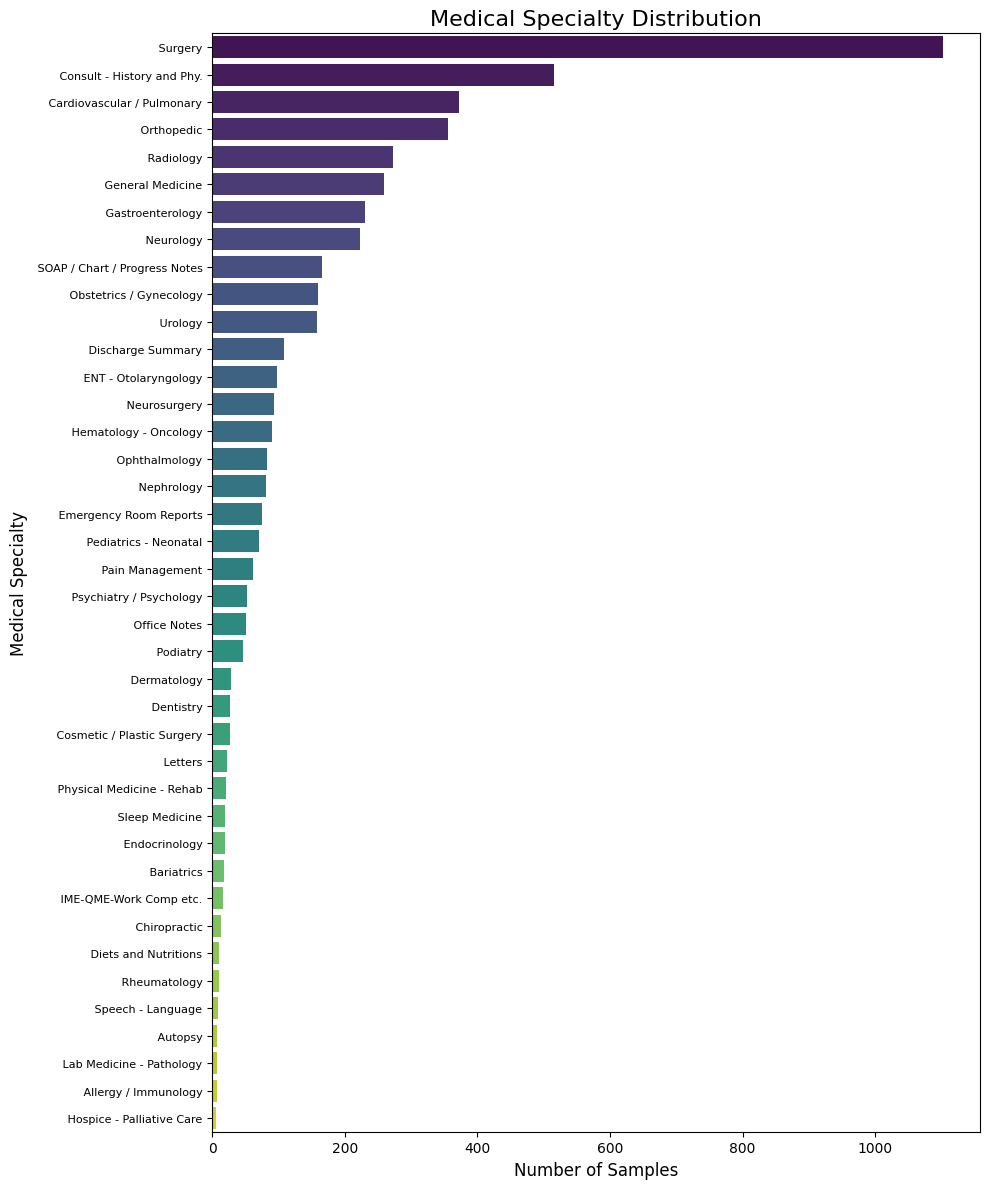

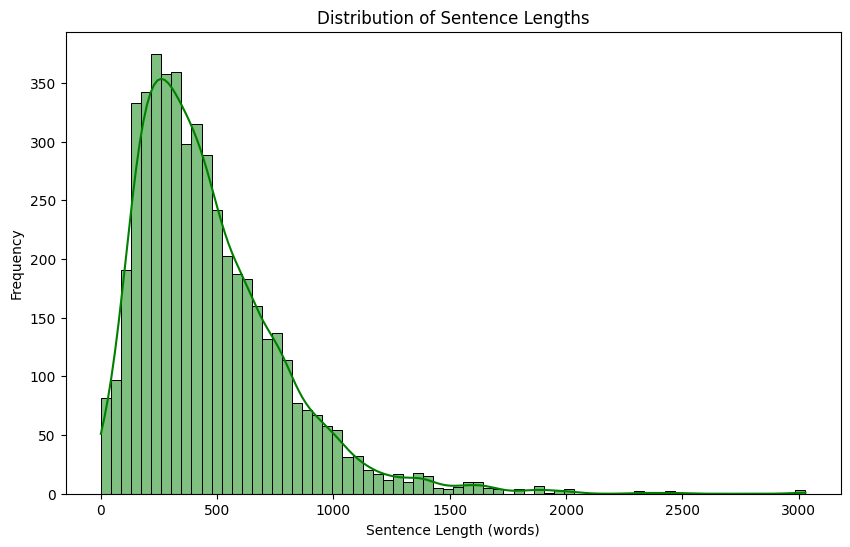

Average sentence length: 465.45 words
Median sentence length: 398.0 words
Max sentence length: 3029 words
Min sentence length: 1 words
Generating plot: Top 20 Most Frequently Occuring Unigrams...


/tmp/ipython-input-4000906071.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


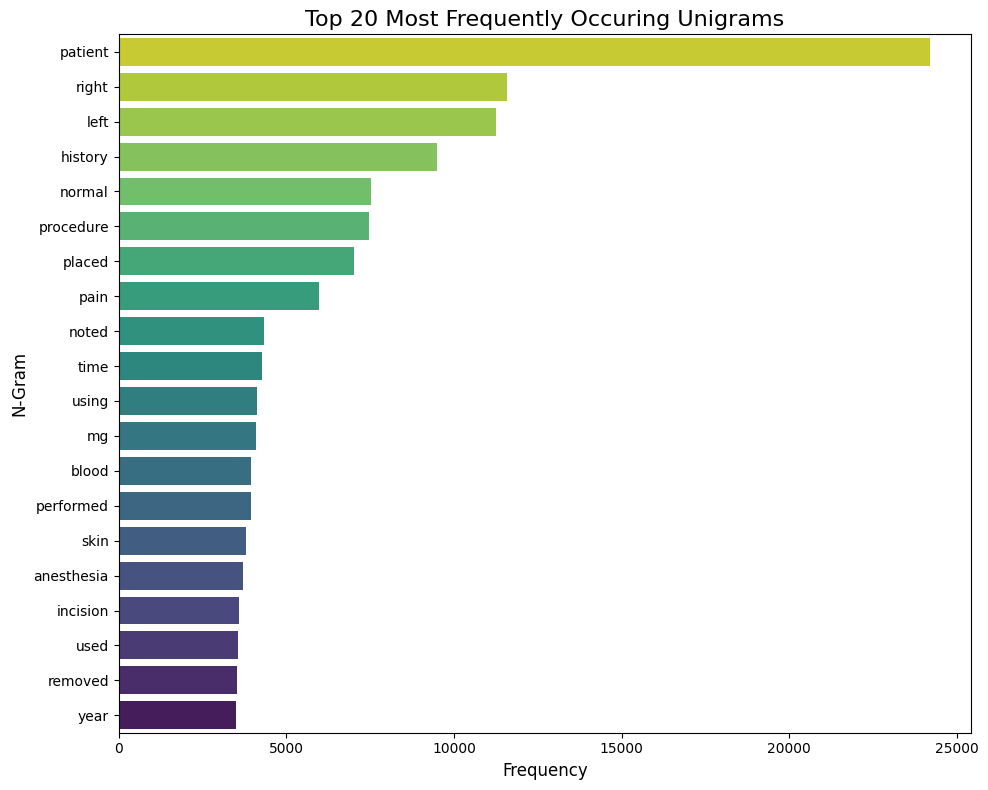

Generating plot: Top 20 Most Frequently Occuring Bigrams...


/tmp/ipython-input-4000906071.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


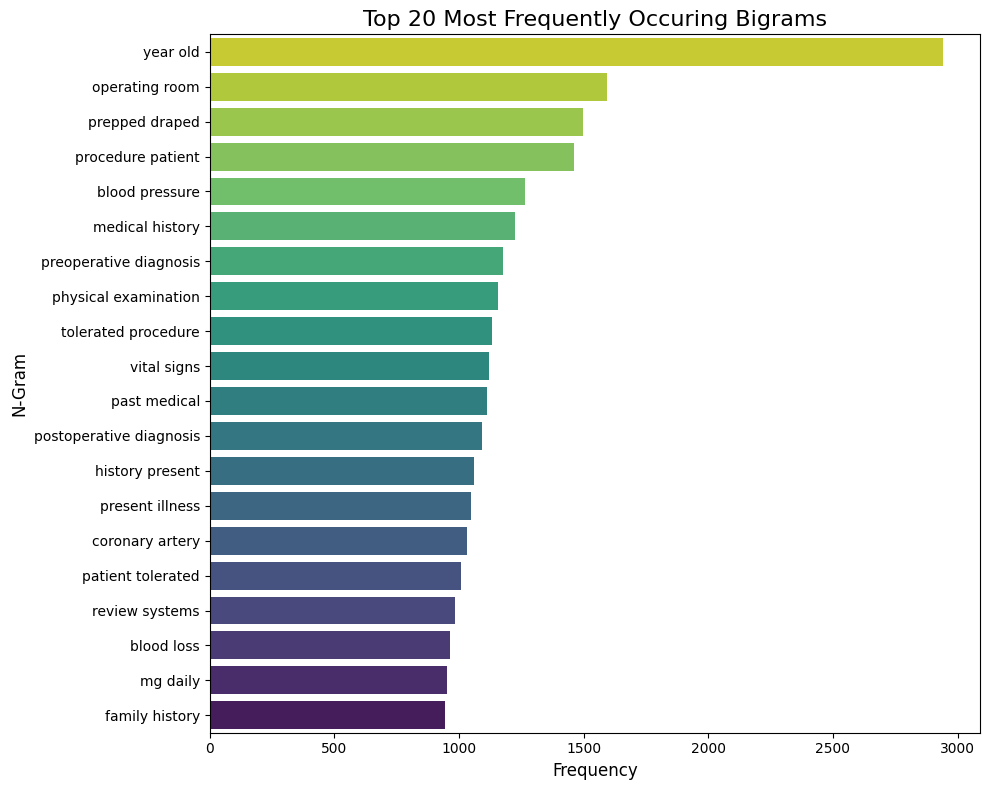

Generating plot: Top 20 Most Frequently Occuring Trigrams...


/tmp/ipython-input-4000906071.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


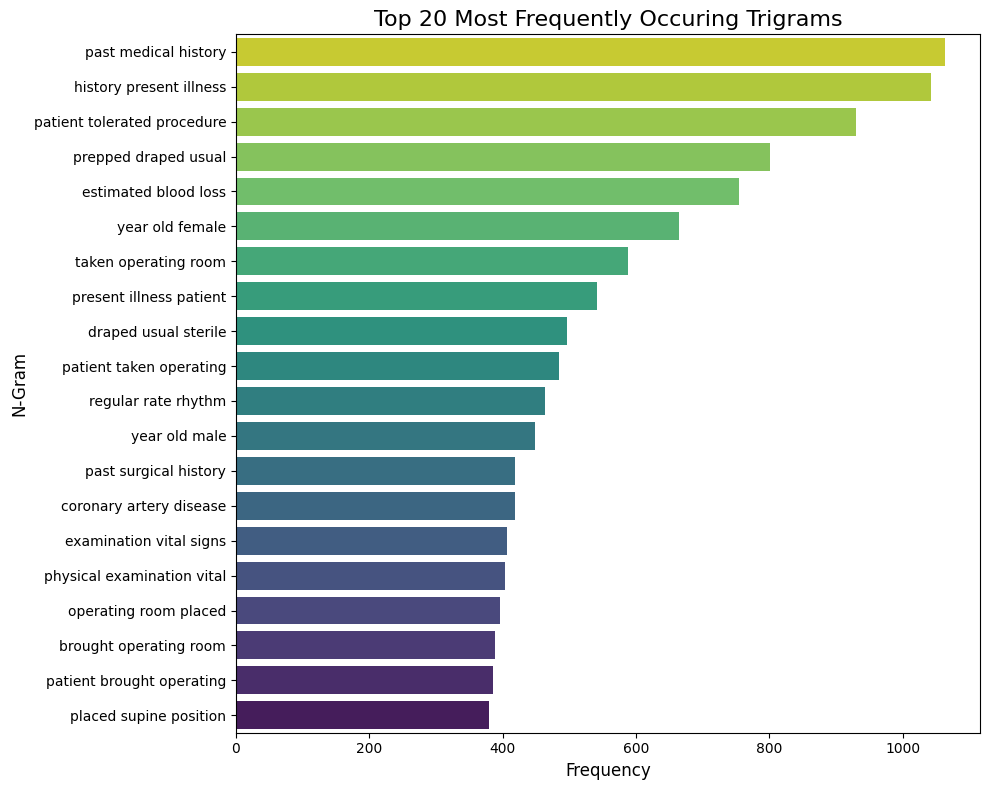

Generating plot: Top 1-grams per Class (Top 6)...
Saved plot to top_1grams_per_class.png
Generating plot: Top 2-grams per Class (Top 6)...
Saved plot to top_2grams_per_class.png
Generating plot: Top 3-grams per Class (Top 6)...
Saved plot to top_3grams_per_class.png
Generating plot: Sentence Lenghts per Class (Top 6)...
Average sentence length for ' Surgery': 484.15 words
Average sentence length for ' Consult - History and Phy.': 558.06 words
Average sentence length for ' Cardiovascular / Pulmonary': 433.60 words
Average sentence length for ' Orthopedic': 559.12 words
Average sentence length for ' Radiology': 274.61 words
Average sentence length for ' General Medicine': 467.10 words
Average sentence length for ' Gastroenterology': 358.69 words
Average sentence length for ' Neurology': 496.31 words
Average sentence length for ' SOAP / Chart / Progress Notes': 358.78 words
Average sentence length for ' Urology': 406.53 words
Average sentence length for ' Obstetrics / Gynecology': 468.32 

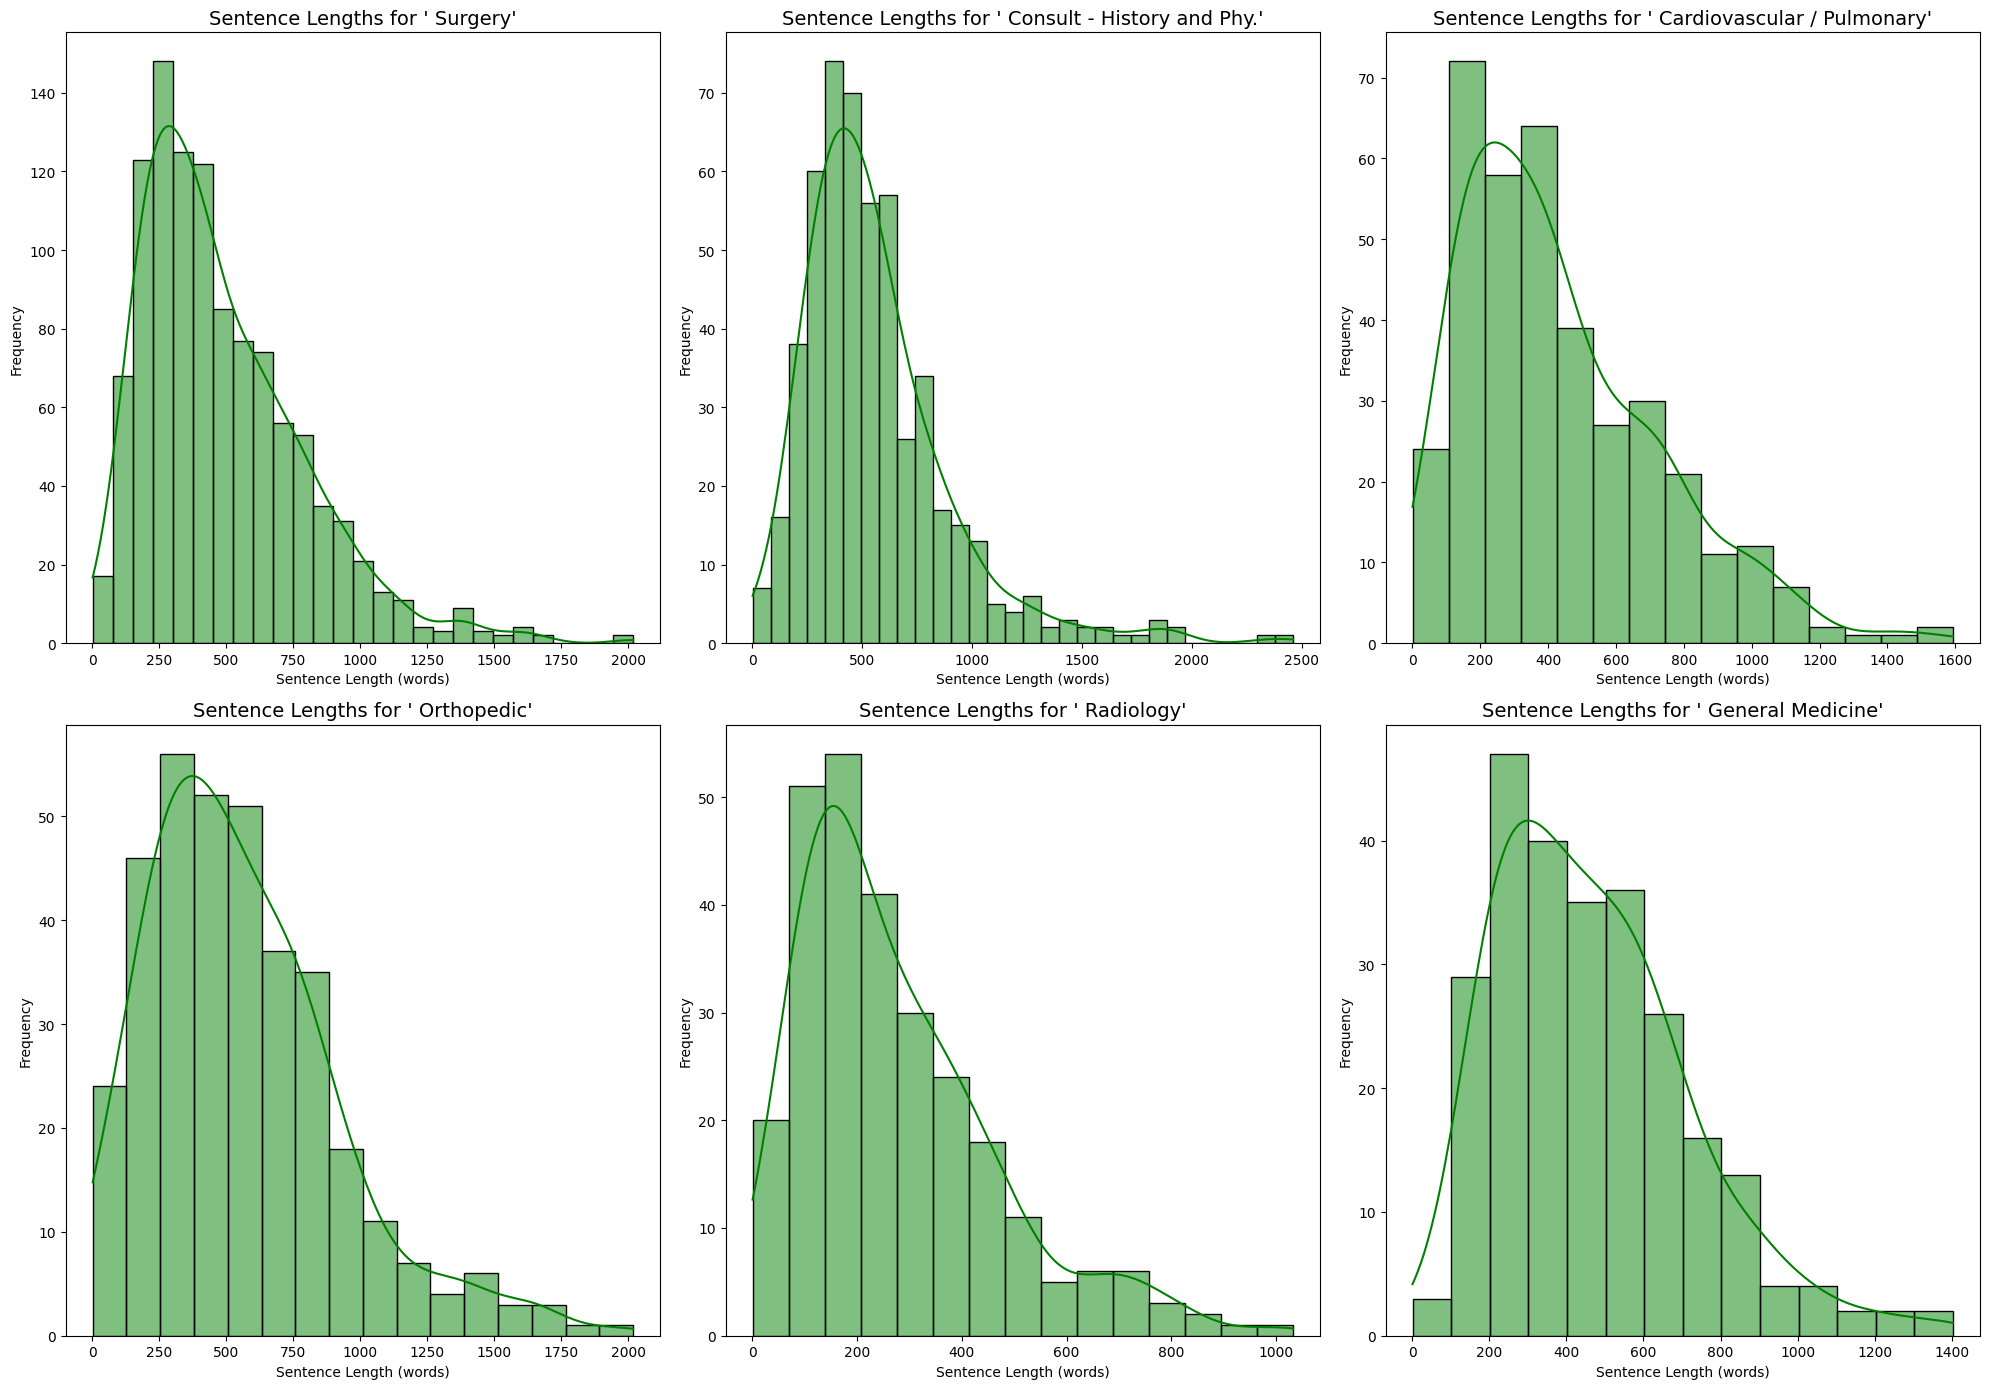

In [ ]:
try:

    plot_label_distribution(raw_data, 'medical_specialty', 'Medical Specialty Distribution', 'medical_specialty_distribution.png')

    text_data = raw_data.dropna(subset=['transcription'])['transcription'] # Remove Nan to avoid errors

    plot_lenghts(text_data)

    # N-grams general

    # Plot for N = 1
    plot_top_ngrams(text_data,n=1,top_k=20,title='Top 20 Most Frequently Occuring Unigrams')

    # Plot for N = 2
    plot_top_ngrams(text_data,n=2,top_k=20,title='Top 20 Most Frequently Occuring Bigrams')

    # Plot for N = 3
    plot_top_ngrams(text_data,n=3,top_k=20,title='Top 20 Most Frequently Occuring Trigrams')

    # N-grams per class:

    # Plot for N = 1
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=1, num_classes=6)

    # Plot for N = 2
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=2, num_classes=6)

    # Plot for N = 3
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=3, num_classes=6)

    # Lenght per class:

    plot_lenghts_per_class(raw_data, 'transcription', 'medical_specialty', num_classes=6)
except KeyError:
    print('"transcription" column not found.')
except Exception as e:
    print(f"An error occurred: {e}")



### **Pre-processing**

Looking at the initial plots, we see that the dataset has **two major problems**:
1. There are some very small but meaningfull classes (Allergy / Immunology - Hospice) with less than 20 samples.
2. There are some noisy and vague noisy classes (Consult - History and Phy SOAP / Chart).

This is a classic "**garbage in - garbage out**" problem where there is the risk of feeding the model with noisy and unbalanced data. This can result in low interpretability and poor performances.  

The idea is to pre-process the data by performing an aggressive **data cleaning** and **data augmentation**. The data cleaning function should:  

1. Drop NaNs and 'Unnamed: 0' column.
2. Merge similar classes ('Neurology' and 'Neurosurgery').
3. Remove a specific list of noisy/document-type labels (letters, office notes, ecc.).
4. Filter out any remaining classes with < min_samples.

The data augmentation will be performed using the "**back translation**" technique. We'll translate the samples in different languages (German, Italian and Russian) to augment the samples without altering the original meaning.

In [ ]:

def pre_processing_data(data, min_samples=50):
    """
    Performs aggressive cleaning of the 'medical_specialty' column
    based on the Model 3 strategy:
    1. Drops NaNs and 'Unnamed: 0' column.
    2. Merges similar classes
    3. Removes a specific list of noisy/document-type labels.
    4. Filters out any remaining classes with < min_samples.

    Inputs:
            "data" = (DataFrame) The raw data to clean.
            "min_samples" = (int) Threshold for the minimum samples per class.

    Output:
            (DataFrame) The pre-processed, cleaned and filtered data.
    """
    print("--- Starting Data Cleaning ---")
    print(f"Original dataset shape: {data.shape}")

    # Make a copy to avoid SettingWithCopyWarning
    data = data.copy()

    # 1. Initial cleanup
    if 'Unnamed: 0' in data.columns:
        data = data.drop(columns=['Unnamed: 0'])

    data['medical_specialty'] = data['medical_specialty'].str.strip()
    data = data.dropna(subset=['transcription', 'medical_specialty'])
    print(f"Shape after dropping NaNs: {data.shape}")

    # 2. Merge similar specialties (we should decide which one)
    merge_map = {
        'Bariatrics': 'Surgery',
        'Cosmetic / Plastic Surgery': 'Surgery',
        'Neurosurgery': 'Neurology / Neurosurgery',
        'Neurology': 'Neurology / Neurosurgery' # Map base class too
    }

    data['medical_specialty'] = data['medical_specialty'].replace(merge_map)
    print("Completed merging 'Bariatrics'/'Cosmetic' into 'Surgery' and 'Neurosurgery' into 'Neurology / Neurosurgery'.")

    # 3. Define and remove "noisy" labels (document types, not specialties)
    noisy_labels = [
        'Consult - History and Phy.',
        'SOAP / Chart / Progress Notes',
        'Discharge Summary',
        'Emergency Room Reports',
        'General Medicine',
        'Radiology',            # Debatable
        'Office Notes',
        'Letters',
        'IME-QME-Work Comp etc.',
        'Lab Medicine - Pathology',
        'Autopsy'               # Debatable
    ]


    noisy_count = data['medical_specialty'].isin(noisy_labels).sum()
    print(f"Found {noisy_count} samples with noisy labels to remove.")

    data = data[~data['medical_specialty'].isin(noisy_labels)]
    print(f"Shape after removing noisy labels: {data.shape}")

    # 4. Handle class imbalance by removing specialties with < min_samples
    specialty_counts = data['medical_specialty'].value_counts()
    specialties_to_keep = specialty_counts[specialty_counts >= min_samples].index

    original_classes = data['medical_specialty'].nunique()
    print(f"Classes before min_sample filter: {original_classes}")

    data = data[data['medical_specialty'].isin(specialties_to_keep)]
    print(f"Shape after removing classes with < {min_samples} samples: {data.shape}")

    final_classes = data['medical_specialty'].nunique()
    print(f"--- Cleaning Complete ---")
    print(f"Final number of classes: {final_classes}")

    return data.reset_index(drop=True)


In [ ]:

try:
     clean_data = pre_processing_data(raw_data, min_samples=50)
     print('Data pre-processing completed successfully.')
except KeyError:
    print('"transcription" or "medical_specialty" column not found.')
except Exception as e:
    print(f"An error occurred: {e}")

print("\n--- New Class Distribution (After Pre-processing) ---")
print(clean_data['medical_specialty'].value_counts())
print('Mean number of samples per class after cleaning:', clean_data['medical_specialty'].value_counts().mean())
print('Median number of samples per class after cleaning:', clean_data['medical_specialty'].value_counts().median())


--- Starting Data Cleaning ---
Original dataset shape: (4999, 6)
Shape after dropping NaNs: (4966, 5)
Completed merging 'Bariatrics'/'Cosmetic' into 'Surgery' and 'Neurosurgery' into 'Neurology / Neurosurgery'.
Found 1502 samples with noisy labels to remove.
Shape after removing noisy labels: (3464, 5)
Classes before min_sample filter: 26
Shape after removing classes with < 50 samples: (3245, 5)
--- Cleaning Complete ---
Final number of classes: 14
Data pre-processing completed successfully.

--- New Class Distribution (After Pre-processing) ---
medical_specialty
Surgery                       1133
Cardiovascular / Pulmonary     371
Orthopedic                     355
Neurology / Neurosurgery       317
Gastroenterology               224
Urology                        156
Obstetrics / Gynecology        155
ENT - Otolaryngology            96
Hematology - Oncology           90
Ophthalmology                   83
Nephrology                      81
Pediatrics - Neonatal           70
Pain Manag

### **Pre-Processing Results:**

The pre-processing left us with 14 classes (labels) to deal with. The dataset is still unbalanced but we managed to remove most of the noisiy labels along with classes with too few samples. Before performing the back translation we plot the results of the pre-procesing below.


Note (W): *We should split the data into test-validation-training before the second EDA as we're only interested in the training set (the others won't be touched by the data augmentation). We can also perform data partitioning after the second EDA but this could result in some "peeking" of the data.*

Here we show the EDA after the pre-processing.

### **Post Pre-processing plots**

Generating plot: Medical Specialty Distribution...


/tmp/ipython-input-4000906071.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


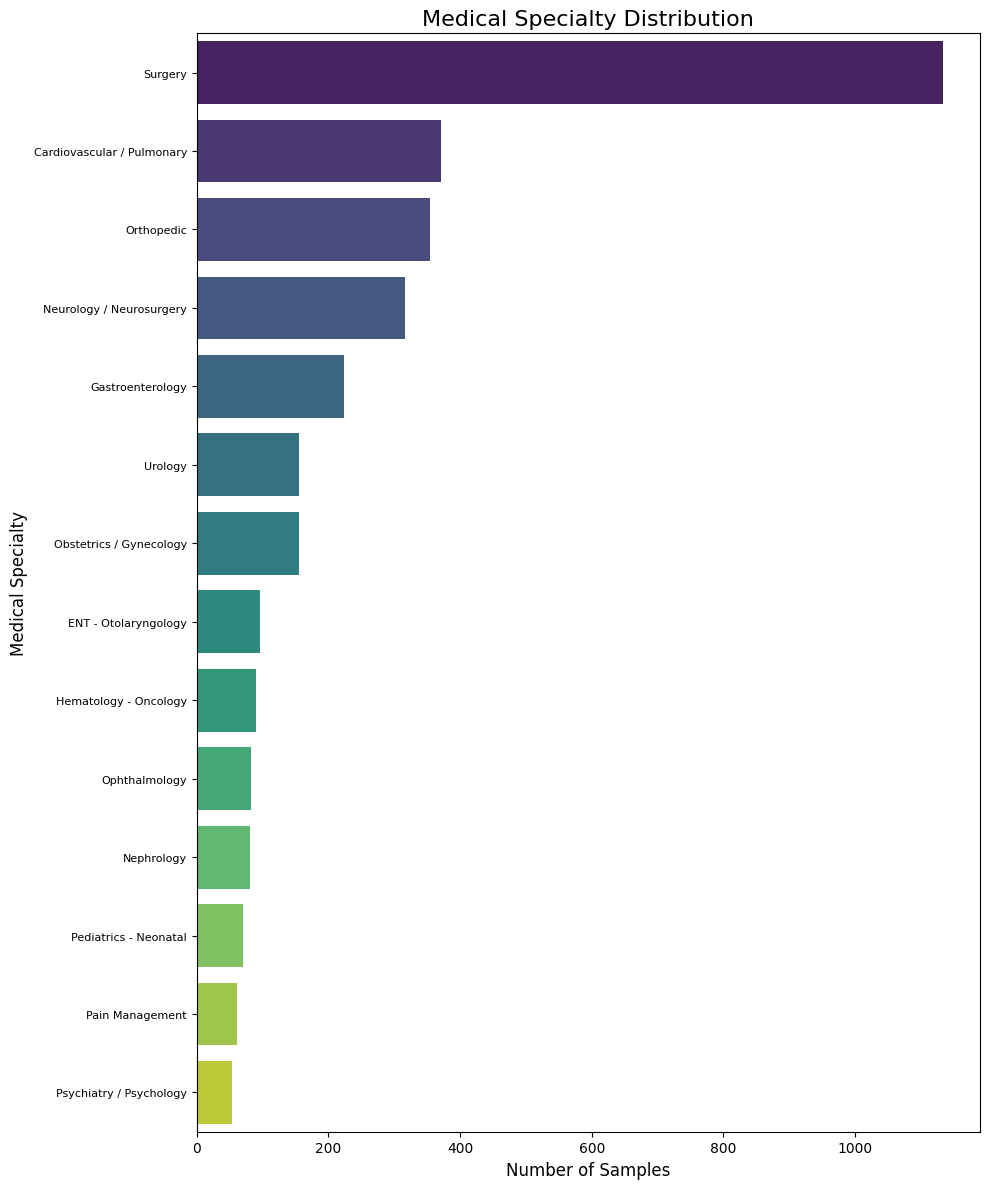

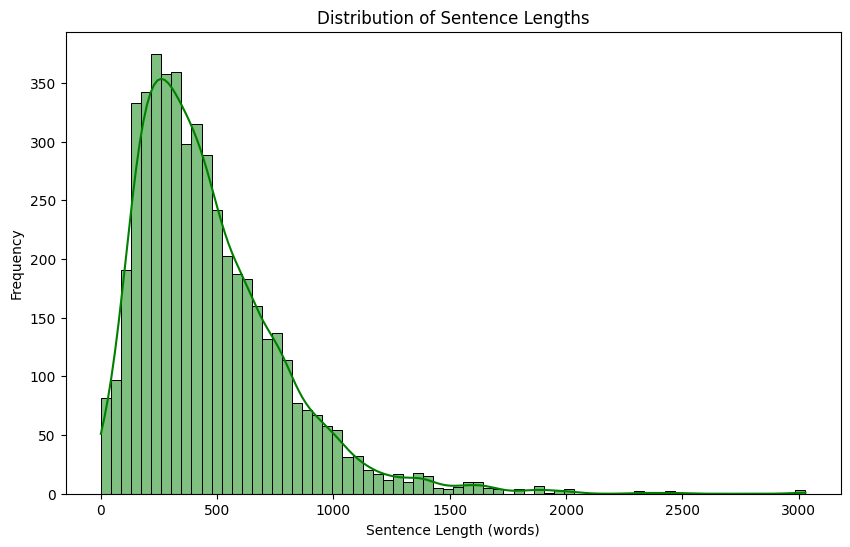

Average sentence length: 465.45 words
Median sentence length: 398.0 words
Max sentence length: 3029 words
Min sentence length: 1 words


In [ ]:
plot_label_distribution(clean_data, 'medical_specialty', 'Medical Specialty Distribution', 'medical_specialty_distribution.png')

text_data = raw_data.dropna(subset=['transcription'])['transcription'] # Remove Nan to avoid errors

plot_lenghts(text_data)

## **4. Data Partitioning:**

We split the data into three sets: Training, Validation and Test. We can change the proportion but i think that 65%-20%-15% can be a good start.

In [ ]:


def data_partition(data, label_col, train_size=0.65, val_size=0.15, test_size=0.20, random_state=15):
    """
    We split the data into Train, Validation and Test keeping the dataframe format.

    Inputs:
            data = (DataFrame) data to partition
            label_col = (string) name of the label column
            train_size = (float) proportion of the data to use for training
            val_size = (float) proportion of the data to use for validation
            test_size = (float) proportion of the data to use for testing
            random_state = (int) seed for reproducibility

    Outputs:
            train_df = (DataFrame) training set
            val_df = (DataFrame) validation set
            test_df = (DataFrame) testing set

    """
    print("--- Starting Data Partitioning ---")
    print("")

    # First split: Train vs (Validation + Test)

    train_df, temp_df = train_test_split(data,test_size=(val_size + test_size),stratify=data[label_col],random_state=random_state)

    # Second split: Validation vs Test

    relative_test_size = test_size / (val_size + test_size)

    val_df, test_df = train_test_split(temp_df,test_size=relative_test_size,stratify=temp_df[label_col],random_state=random_state)

    # Reset index to avoid further problmes
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"Train DF shape: {train_df.shape}")
    print(f"Val DF shape:   {val_df.shape}")
    print(f"Test DF shape:  {test_df.shape}")

    # We add a small barplot to show the proportions:
    # Create a summary dataframe for plotting
    split_counts_data = {'Split': ['Train', 'Validation', 'Test'],'Count': [len(train_df), len(val_df), len(test_df)]}
    split_counts_df = pd.DataFrame(split_counts_data)

    print("")

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Split', y='Count', data=split_counts_df, palette='muted', hue='Split', legend='auto')
    plt.title('Distribution of Data Across Splits', fontsize=16)
    plt.xlabel('Split', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.show()

    print("")
    print("--- Data Partitioning Complete ---")


    return train_df, val_df, test_df


--- Starting Data Partitioning ---

Train DF shape: (2109, 5)
Val DF shape:   (486, 5)
Test DF shape:  (650, 5)



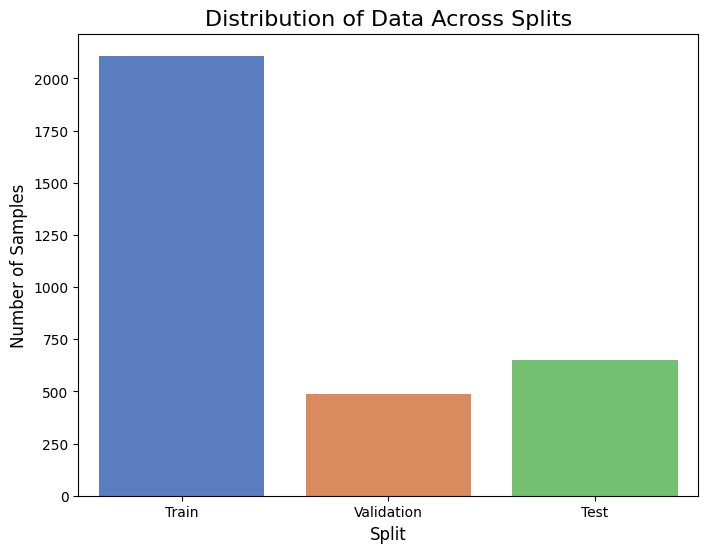


--- Data Partitioning Complete ---
Training set shape:

medical_specialty
Surgery                       736
Cardiovascular / Pulmonary    241
Orthopedic                    231
Neurology / Neurosurgery      206
Gastroenterology              146
Obstetrics / Gynecology       101
Urology                       101
ENT - Otolaryngology           62
Hematology - Oncology          58
Ophthalmology                  54
Nephrology                     53
Pediatrics - Neonatal          46
Pain Management                40
Psychiatry / Psychology        34
Name: count, dtype: int64

Validation set shape:

medical_specialty
Surgery                       170
Cardiovascular / Pulmonary     56
Orthopedic                     53
Neurology / Neurosurgery       47
Gastroenterology               33
Urology                        24
Obstetrics / Gynecology        23
ENT - Otolaryngology           15
Hematology - Oncology          14
Ophthalmology                  12
Nephrology                     12
Pediatr

In [ ]:
train_df, val_df, test_df = data_partition(clean_data, 'medical_specialty')

# We can print the number of samples for each class:

print('Training set shape:')
print('')
print(train_df['medical_specialty'].value_counts())
print('')
print('Validation set shape:')
print('')
print(val_df['medical_specialty'].value_counts())
print('')
print('Test set shape:')
print('')
print(test_df['medical_specialty'].value_counts())

# Questi print sono tanto aberranti quanto funzionanti...

## **5. Data Augmentation**

### **Back Translation:**

Here we define the function for the back translation. Important: To avoid **data leakage** the test/train split must be performed before the back translation. We should augment only the training set.

Back Tranlation aletrnatives:

- Random Swap: Randomly choose two words in the sentence and swap their positions. Do this n times. (fast n easy)

- Random Insertion: Find a random synonym of a random word in the sentence that is not a stop word. Insert that synonym into a random position in the sentence. Do this n times. (fast n easy)

- Shuffle Sentences Transform: In this transformation, if the given text sample contains multiple sentences these sentences are shuffled to create a new sample. (Albumentation library)

Note: I like the Helsinky models (proposed from Luca) better as they're faster and smoother than meta (facebook) models. I thinks we should use them.

In [ ]:
def data_augmentation_dual_back_translation(df, text_col, label_col, augmentation_ratio=1.0, max_samples_limit=300):
    """
    Performs Back Translation using both intermediate languages (German and Italian)
    to increase variance. The number of samples generated is proportional to the
    original class size to avoid excessive synthetic data. If max_samples_limit is set,
    it caps the generation so that (original + new) <= limit.

    Inputs:
            df (DataFrame): Input training dataframe.
            text_col (str): Name of the text column.
            label_col (str): Name of the label column.
            augmentation_ratio (float): How many new samples to generate per original sample.
                                        1.0 = double the data (1 original + 1 fake).
                                        2.0 = triple the data (1 original + 2 fake).
                                        Keep <= 2.0 to ensure fake data is not > 2/3 of total.
            max_samples_limit (int): Optional cap. If a class already has this many samples,
                                     it won't be augmented.

    Output:
            final_df (DataFrame): The dataframe with original + augmented data.
    """

    print(f"\n--- Starting Dual-Language Back Translation (German & Italian) ---")

    # Check for GPU or CPU:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    if device == 'cpu':
        print("WARNING: Running on CPU will be extremely slow.")

    # Initialize both models
    print("Loading translation models...")

    # German Pair
    aug_de = naw.BackTranslationAug(
        from_model_name='Helsinki-NLP/opus-mt-en-de',
        to_model_name='Helsinki-NLP/opus-mt-de-en',
        device=device,
        batch_size=32, # Increased batch size for speed (maybe we can push to 32)
        max_length=300
    )

    # Italian Pair
    aug_it = naw.BackTranslationAug(
        from_model_name='Helsinki-NLP/opus-mt-en-it',
        to_model_name='Helsinki-NLP/opus-mt-it-en',
        device=device,
        batch_size=32,
        max_length=300
    )

    class_counts = df[label_col].value_counts()
    new_rows = []


    def get_needed_samples(current_count, ratio, limit):
        """
        Calculates the exact number of new samples to generate for a class.
        It compares the augmentation target against the hard limit to ensure
        the final count never exceeds 'max_samples_limit'.

        Inputs:
                current_count (int) = Current number of samples for the specific class.
                ratio (float)       = The augmentation ratio (e.g., 1.0 = double the data).
                limit (int)         = The maximum allowed total samples (cap).

        Output:
                int = The number of samples to generate (the minimum between
                      the ratio-target and the remaining space).
        """
        # Calculate target based on ratio
        target_increase = int(current_count * ratio)

        # If no limit exists, return the ratio-based target
        if not limit:
            return target_increase

        # If limit exists, calculate space remaining
        space_remaining = limit - current_count

        # If class is already larger than limit, we need 0
        if space_remaining <= 0:
            return 0

        # Return the smaller of the two: (Ratio Target vs Space Remaining)
        return min(target_increase, space_remaining)

    # 2. Total sample estiamte:
    total_new_samples = 0
    for label, count in class_counts.items():
        total_new_samples += get_needed_samples(count, augmentation_ratio, max_samples_limit)

    print(f"\nTotal samples to generate: {total_new_samples}")

    if total_new_samples == 0:
        print("No samples needed based on current limits/ratios.")
        return df

    # Warning checks
    if augmentation_ratio >= 2:
        print('--- Warning! ---')
        print('Ratio is high (>2.0)')
        print('Be aware that more than 2/3 of the data will be synthetic.')
        print('--- Warning! ---')

    # Time Estimate: around 4 seconds per sample (conservative estimate)
    est_minutes = (total_new_samples * 4) / 60
    print(f"Estimated runtime: ~{est_minutes:.1f} minutes...")
    if est_minutes > 60:
        print(f"Estimated runtime: ~{est_minutes / 60:.1f} hours...")
    print("-" * 60)

    # Loop:
    for label, count in class_counts.items():

        # Calculate needed samples:
        n_total_needed = get_needed_samples(count, augmentation_ratio, max_samples_limit)

        # Skip if nothing to generate
        if n_total_needed <= 0:
            print(f"Class '{label}' already has {count} samples. Skipping...")
            continue

        # Split evenly between German and Italian
        n_german = math.ceil(n_total_needed / 2)
        n_italian = n_total_needed - n_german

        samples = df[df[label_col] == label][text_col].tolist()

        print(f"Class '{label}': Original={count} | Generating {n_german} (DE) + {n_italian} (IT) | Final Class Size will be: {count + n_total_needed}")


        def generate_batch(augmenter, target_n, source_texts):
            """
            Executes the back-translation loop for a specific language model.
            It handles text truncation to avoid model errors and updates a
            progress bar for real-time feedback.

            Inputs:
                    augmenter (object)  = The loaded nlpaug model (German or Italian).
                    target_n (int)      = The specific target number of samples to generate.
                    source_texts (list) = List of original text strings to use as source.

            Output:
                    generated_batch (list) = A list of dictionaries containing the
                                             new augmented text and label.
            """
            generated_batch = []
            gen_count = 0

            # Loading bar creation:
            with tqdm(total=target_n, leave=False, desc=f"Gen for {label}") as pbar:
                while gen_count < target_n:
                    for text in source_texts:
                        if gen_count >= target_n:
                            break

                        # Pre-check text length
                        if not isinstance(text, str) or len(text) < 10:
                            continue

                        # Truncate to fit model max_length roughly (very roughly)
                        proc_text = text[:1000] if len(text) > 1000 else text

                        try:
                            # Augment
                            res = augmenter.augment(proc_text)
                            aug_text = res[0] if isinstance(res, list) else res

                            generated_batch.append({text_col: aug_text, label_col: label})
                            gen_count += 1
                            pbar.update(1)
                        except Exception:
                            continue
            return generated_batch

        #  German samples
        if n_german > 0:
            new_rows.extend(generate_batch(aug_de, n_german, samples))

        #  Italian samples
        if n_italian > 0:
            new_rows.extend(generate_batch(aug_it, n_italian, samples))

    # 4. Final part:
    if len(new_rows) > 0:
        aug_df = pd.DataFrame(new_rows)
        # Concatenate and Shuffle
        final_df = pd.concat([df, aug_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

        print(f"\n--- Augmentation Complete ---")
        print(f"Original Samples: {len(df)}")
        print(f"Augmented Samples: {len(new_rows)}")
        print(f"Total Samples: {len(final_df)}")
        return final_df
    else:
        print("No samples generated.")
        return df

In [ ]:


# Dataset A. 100% BT:

BT_GI_full_augmented_train_df = data_augmentation_dual_back_translation(
    train_df,
    text_col='transcription',
    label_col='medical_specialty',
    augmentation_ratio=1.0,
    max_samples_limit=300
)

# Save the dataframe so we do it only once:

BT_GI_full_augmented_train_df.to_csv('full_augmented_train_df.csv', index=False)
print('New dataframe saved!')

# Verify results
print('New dataframe:')
print(BT_GI_full_augmented_train_df['medical_specialty'].value_counts())






### **Summary Augmentation**

Here we do the abstract summary augmentation through the usage of BART model from HuggingFace.

This method consists in asking a transformer model to summarize the content of a string so that it creates an artificial sample we can utilize to mitigate class disparities. We use FalconsAi transfomer model for medical summarization available on: https://huggingface.co/Falconsai/medical_summarization. This T5 Large language model with 60.5 M parameters was designed specifically for summarizing medical and healthcare-related documents. More informations are available in the HuggingFace webpage.


The main summary function will works as described:

First we'll set the number of samples for each class to reach:
- For those who already exceed the number of samples we will not do data augmentation.
- For those who lack samples we will proceed with the summary augmentation

In [ ]:


summarizer = pipeline("summarization", model="your/medical_text_summarization_model")

print(summarizer(MEDICAL_DOCUMENT, max_length=2000, min_length=1500, do_sample=False))

Function per l'augmentation


In [ ]:
def data_augmentation_summary(df, text_col, label_col, max_samples_limit=300):
  """
  Performs augmented summarization using a transformer model.
  The number of samples generated is proportional to the original class size to avoid excessive synthetic data.
  If max_samples_limit is set, it caps the generation so that (original + new) <= limit.


  Inputs:

            df (dataframe)  = Input training dataframe.
            text_col (str)  = Name of the text column.
            label_col (str) = Name of the label column.
            max_samples_limit (int) = Optional cap. If a class already has this many samples, it won't be augmented.

  Output:

            df_augmented (dataframe) = The dataframe with original + augmented data


  """

  # Check for GPU or CPU:
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  print(f"Using device: {device}")
  if device == 'cpu':
      print("WARNING: Running on CPU will be extremely slow.")

  #Defining the function that will count elements per class
  def class_counting(df, label_col, max_samples_limit):

    samples_per_class = df[label_col].value_counts()
    difference = max_samples_limit - samples_per_class
    final = difference.clip(lower=0)

    return final


  samples_to_generate=class_counting(df, label_col, max_samples_limit)

  augmented_rows = []

  for class_name, count in samples_to_generate.items():

    if count == 0:
            continue

    #Generating a temporary dataframe to store all the samples in the class we're analyzing
    df_tmp=df[df[label_col]==class_name].reset_index(drop=True)

    for i in range(count):

      """by using this counter method if the class has less then half of the needed samples
      i keep rotating them without getting index errors, also this makes it more reproducable
      insteead of the classic rand function"""
      counter = i % len(df_tmp)
      sample = df_tmp.iloc[counter]

      txt_to_sum = sample[text_col]

      #This if is to double check the string we get as input
      if not isinstance(txt_to_sum, str) or len(txt_to_sum.strip()) == 0:
        print("Empty or simply not a string")
        continue

      """The core of the function
      do_sample if set False generates always the same output, because it takes
      word with the max probability
      Here i set it to True so that it randomly takes one of the most probable words
      so that we don't end up with the same generated samples
      Unfortunately by doing this the results won't be reproducible"""

      try:

        #The output is a list so i manage it to get a string
        new_txt=summarizer(txt_to_sum, max_length=130, min_length=20, do_sample=True)[0]["summary_text"]

        new_sample = sample.copy()
        new_sample[text_col] = new_txt
        augmented_rows.append(new_sample)

      except:

        print("Error in the summarization")
        continue

  #Append the new rows to the original dataframe in order to check the goo
  df_augmented = pd.concat([df, pd.DataFrame(augmented_rows)], ignore_index=True)

  return df_augmented

In [ ]:
summarizer = pipeline("summarization", model="Falconsai/medical_summarization")

AS_full_augmented_train_df = data_augmentation_summary(
    train_df,
    text_col='transcription',
    label_col='medical_specialty',


    max_samples_limit= 300
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Token indices sequence length is longer than the specified maximum sequence length for this model (551 > 512). Running this sequence through the model will result in indexing errors


Using device: cuda


Both `max_new_tokens` (=256) and `max_length`(=130) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=130) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=130) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=130) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
# Save the augmented dataframe so we do it only once:

AS_full_augmented_train_df.to_csv('AS_full_augmented_train_df.csv', index=False)
print('New dataframe saved!')

# Verify results
print('New dataframe:')
print(AS_full_augmented_train_df['medical_specialty'].value_counts())

New dataframe saved!
New dataframe:
medical_specialty
Surgery                       736
Orthopedic                    300
Cardiovascular / Pulmonary    300
Hematology - Oncology         300
Pediatrics - Neonatal         300
Gastroenterology              300
Neurology / Neurosurgery      300
Ophthalmology                 300
Obstetrics / Gynecology       300
Nephrology                    300
ENT - Otolaryngology          300
Urology                       300
Pain Management               300
Psychiatry / Psychology       300
Name: count, dtype: int64


At the end of the data Augmentation we end up with 3 training datasets:

1. Full back translation augmented dataset:

2. Partial BT and partial abstract summary augmented dataset:

3. Full abstract summary augmented dataset:

# **6. Model selection:**

Here we'll select the model (or models) to train with. I think we can try 2 models, one "classic" model (RNNs or CNN) that will perform very poorly (just like the logistic regression from the other guy). The other model will be a "state of the art" transformer based model (likely ClinicalBERT / BioBERT or somth like that). This second model will not only be theoretically correct (as transformers are designed for this task) but will also have way better performances. In particular, we'll use Emily Alsentzer Bio_ClinicalBERT which is pre-trained on MIMIC-III data.





❗ **Diario di bordo**

Piccolo siparietto da mettere nel diario di bordo:
La chiave di questa cella è la funzione "AutoModelForSequenceClassification.from_pretrained".

Questa funzione di alto livello è prodotta direttamente dalla libreria di transoformers di Hugging Face.

La function fa due cose importanti:
  - Carica il "corpo" del modello specificato pre-allenato con tutti i pesi.
  - Aggiunge il layer o testa di classificazione alla fine del "corpo". Questo layer è inizializzato con **pesi casuali** che andranno imparati attraverso il fine tuning.

  Per quanto riguarda i parametri della function sono abbastanza semplici da decidere ma consiglio comunque di dare uno sguardo per sicurezza.

## **RNN (Recurrent Neural Network)**





## **ClinicalBERT**  :

We now load the "Bio_ClinicalBERT" model from Hugging Face. The model was trained on all notes from MIMIC III, a database containing electronic health records from ICU patients at the Beth Israel Hospital in Boston, MA. Moreover, the model was trained with PubMed 200K, a dataset of approximately 200,000 abstracts of randomized controlled trials, totaling 2.3 million sentences. More details regarding pre-training procedures and hyperparameters can be found at https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT. Other information about the base BERT model are linked here https://github.com/google-research/bert.

In [ ]:

labels_list = train_df['medical_specialty'].unique().tolist()
label_map = {label: i for i, label in enumerate(labels_list)}
Model_name = "emilyalsentzer/Bio_ClinicalBERT"
Num_labels = train_df['medical_specialty'].nunique()
tokenizer = AutoTokenizer.from_pretrained(Model_name)


def get_fresh_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        "emilyalsentzer/Bio_ClinicalBERT",
        num_labels=len(label_map),
        problem_type="single_label_classification",
        id2label={str(i): label for i, label in enumerate(train_df['medical_specialty'].unique())},
        label2id={label: str(i) for i, label in enumerate(train_df['medical_specialty'].unique())},
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f" Using device: {device}")
    model.to(device)
    print("Fresh ClinicalBERT model loaded successfully and moved to device.")

    return model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
def initialize_bias(model, train_df, label_map, device):
    """
    Initialize the last layer's bias to reflect the real class distribution to ensure that the
    focal loss function converges.
    """
    print(" Custom bias initialization ")

    # Set the count with the same id order in the label_map
    counts = []
    # Order the label_map with ID (0,1,2 ...) just to be sure

    sorted_labels = sorted(label_map.items(), key=lambda item: item[1])

    for label_str, label_id in sorted_labels:
        # Count how many times that label is in the training set
        n = train_df[train_df['medical_specialty'] == label_str].shape[0]
        counts.append(n)

    counts = np.array(counts)
    total = counts.sum()

    # Calculate the "prior" probability: P(class)

    # Add a small epsilon to avoid log(0)

    priors = counts / total

    # Calculate ideal bias: b = log(P(class))

    initial_bias = np.log(priors + 1e-7)

    # 4. Apply to the model :
    with torch.no_grad():
        if hasattr(model, 'classifier') and hasattr(model.classifier, 'bias'):
            model.classifier.bias.data = torch.tensor(initial_bias, dtype=torch.float32).to(device)
            print("Bias correctly applied with respect to the classes.")
        else:
            print("ERROR: can't find model.classifier.bias")

### **A. Dataset conversion**

We can't feed the model the pandas df so we define a "Dataset" class that  converts the pandas dataframe into a PyTorch-compatible datasets that handle tokenization.

In [ ]:
class Torch_dataframe(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512, label_map=None):
        """
        Inputs:
            texts (list or Series)  =  The text data.
            labels (list or Series) =  The string labels.
            tokenizer               =  The Hugging Face tokenizer.
            max_len                 =  Max token length (Bio_ClinicalBERT max is 512).
            label_map               =  Dictionary mapping string labels to integers.
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.label_map = label_map

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        # Ensure we get the string whether it's a list or a pandas Series/Index
        text = str(self.texts[idx]) if isinstance(self.texts, list) else str(self.texts.iloc[idx])

        # Handle label access similarly
        if isinstance(self.labels, list):
            label_str = self.labels[idx]
        else:
            label_str = self.labels.iloc[idx]

        # Map string label to integer
        label = self.label_map[label_str]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Create label map (String to Int)

BT_GI_full_augmented_train_df = pd.read_csv('full_augmented_train_df.csv')

print(f"Label Map: {label_map}")

# Appply the Datasets conversion:

# Training:
train_dataset = Torch_dataframe(
    texts=BT_GI_full_augmented_train_df['transcription'].tolist(),
    labels=BT_GI_full_augmented_train_df['medical_specialty'].tolist(),
    tokenizer=tokenizer,
    max_len=512,
    label_map=label_map
)

# Validation:
val_dataset = Torch_dataframe(
    texts=val_df['transcription'].tolist(),
    labels=val_df['medical_specialty'].tolist(),
    tokenizer=tokenizer,
    max_len=512,
    label_map=label_map
)

# Test set will be converted only after the training to avoid data leakage.

Label Map: {'Orthopedic': 0, 'Surgery': 1, 'Cardiovascular / Pulmonary': 2, 'Hematology - Oncology': 3, 'Pediatrics - Neonatal': 4, 'Gastroenterology': 5, 'Neurology / Neurosurgery': 6, 'Ophthalmology': 7, 'Obstetrics / Gynecology': 8, 'Nephrology': 9, 'ENT - Otolaryngology': 10, 'Urology': 11, 'Pain Management': 12, 'Psychiatry / Psychology': 13}


### **B. Model Training**

My idea is to make an "Iterative approach" to the training part of the model. We start with a standard cross entropy loss function that should act as baseline.

Then we'll try a weighted loss function, with balanced weights depending on the classes, and finally a Focal loss function approach.

The idea behind this is to exploit the cross entrophy loss using the mathematical formula for Focal Loss:

$
        F_L(p_t) =  - \alpha ⋅ (1 - p_t)^\gamma ⋅ \log(p_t)
$
   
Where:
-   α = class weight (balanced for all the classes)
-   γ = focusing parameter

The gamma parameter handles easy vs hard examples. If the model is 99% sure ($p_t$​ around 0.99), the term $(1−0.99)^γ$ becomes nearly zero, effectively muting the loss for that easy example so the model focuses on the hard ones.

Basically, if the model is "sure" about a classification, that prediction will weights less in the loss function, if the model is unsure of the classification, an eventual error will weight more.

In [ ]:
# We define the class weights (alpha)

def class_weights(df, label_col, device):
    """
    Computes inverse class weights.

    df (dataframe)  = data to get the weights from
    label_col (col) = label column
    device          = device to store the weights on (GPU)

    """
    # Get all unique labels
    classes = np.unique(df[label_col])

    # Compute sklearn class weights (balanced)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=df[label_col]
    )

    # Convert to tensor
    return torch.tensor(weights, dtype=torch.float).to(device)




In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.
    It combines Cross-Entropy Loss with a modulating factor (1 - p_t)^gamma
    and incorporates a class-balancing factor (alpha).
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Per-class weights (torch.Tensor)
        self.gamma = gamma  # Focusing parameter
        self.reduction = reduction

        # Standard CrossEntropyLoss with reduction='none' for per-element loss
        # We pass self.alpha as the 'weight' parameter to nn.CrossEntropyLoss
        self.cross_entropy_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')

    def forward(self, inputs, targets):
        # Compute Cross Entropy Loss (unreduced)
        ce_loss = self.cross_entropy_loss(inputs, targets)

        # Get the probability of the true class (p_t)
        p_t = torch.gather(inputs.softmax(dim=1), 1, targets.view(-1, 1)).squeeze()

        # Compute the modulating factor (1 - p_t)^gamma
        modulating_factor = torch.pow((1.0 - p_t), self.gamma)

        # Final Focal Loss
        focal_loss = modulating_factor * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
def loss_function(loss_type, device, df=None, label_col=None, gamma=2.0):
    """
    Factory function to return the correct loss function based on configuration.

    NOTE: The weights parameter in nn.CrossEntropyLoss is equivalent to the 'alpha'
    balancing factor in Focal Loss when not considering the modulation term gamma.
    """

    # Calculate weights if needed
    if loss_type in ['weighted', 'focal']:
        weights = class_weights(df, label_col, device)
    else:
        weights = None

    # Return the requested loss function
    if loss_type == 'standard':
        print("Selected Loss: Standard Cross Entropy")
        return nn.CrossEntropyLoss()

    elif loss_type == 'weighted':
        print("Selected Loss: Weighted Cross Entropy")
        return nn.CrossEntropyLoss(weight=weights)

    elif loss_type == 'focal':
        print(f"Selected Loss: Focal Loss (gamma={gamma})")
        return FocalLoss(alpha=weights, gamma=gamma)

    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

In [ ]:

def train_model_flexible(model, train_df, val_df, tokenizer, label_map, loss_type='standard', epochs=3, batch_size=16, max_len=512, gamma=2.0):
    """
    This is the final function for the ClinicalBERT training.

    Inputs:
        model                = ClinicalBERT (or any other model)
        train_df (DataFrame) = Training data
        val_df (DataFrame)   = Validation data
        tokenizer            = Hugging Face tokenizer
        label_map (dict)     = Dictionary mapping string labels to integer IDs.
        loss_type (str)      = Loss function selection: 'standard', 'weighted', or 'focal'
        epochs (int)         = Number of training epochs
        batch_size (int)     = Batch size for DataLoader
        max_len (int)        = Maximum token sequence length (BERT has 512).
        gamma (float)        = Focusing parameter for Focal Loss (only used if loss_type='focal').

    Outputs:
        model (object)       = The trained model.
        history (dict)       = Dictionary of training metrics.
    """

    # A. Setup Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)


    # B. Apply Bias Initialization (Only for Focal Loss)
    if loss_type == 'focal':
        initialize_bias(model, train_df, label_map, device)
        print("Initializing bias with Focal Loss function")

    # C. Select Loss Function dynamically
    criterion = loss_function(loss_type, device, train_df, 'medical_specialty', gamma=gamma)

    # D. Data Loaders

    print("Preparing DataLoaders...")

    # Note: Passing the raw Series directly; the robust Dataset class handles it.
    train_dataset = Torch_dataframe(
        train_df['transcription'], train_df['medical_specialty'],
        tokenizer, max_len, label_map
    )
    val_dataset = Torch_dataframe(
        val_df['transcription'], val_df['medical_specialty'],
        tokenizer, max_len, label_map
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # E. Optimizer & Scheduler
    # Here we could try many different lr or something fancy like "warmup learning rate" but for now it's ok

    optimizer = AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    # F. Metrics Storage & Checkpointing
    history = {
        'train_loss': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [],
        'val_f1_weighted': [], 'val_f1_macro': [],
        'val_mcc': [],
        'val_top3_acc': []
    }

    # Model Checkpointing variables
    best_val_f1 = 0.0
    best_model_state = None

    # G. Training Loop
    print(f"\nStarting training for {epochs} epochs...")

    for epoch in range(epochs):
        print(f'\n=== Epoch {epoch + 1}/{epochs} ===')

        # Training Phase
        model.train()
        total_train_loss = 0
        train_preds = []
        train_labels = []

        # Loading bars (TQDM) for the training loop
        train_loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}", unit="batch")

        for batch in train_loop:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Compute Loss
            loss = criterion(logits, labels)

            # Backpropagation
            loss.backward()

            # Gradient Clipping (avoid explosion)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

            # Collect predictions for Training F1 calculation
            _, preds = torch.max(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

            # Update progress bar with current loss
            train_loop.set_postfix(loss=loss.item())

        # Calculate Training Metrics
        avg_train_loss = total_train_loss / len(train_loader)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')

        print(f"  -> Avg Train Loss: {avg_train_loss:.4f} | Train F1 (Weighted): {train_f1:.4f}")

        # Validation Phase:
        model.eval()
        total_val_loss = 0
        val_preds = []
        val_labels = []
        val_probs = []

        # Loading bars (TQDM) for the validation loop
        val_loop = tqdm(val_loader, desc=f"Validating Epoch {epoch+1}", unit="batch")

        with torch.no_grad():
            for batch in val_loop:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits

                # Get probabilities (Softmax) for Top-k
                probs = torch.nn.functional.softmax(logits, dim=1)

                # Calculate Val Loss (useful to see if it diverges from Train Loss)
                loss = criterion(logits, labels)
                total_val_loss += loss.item()

                _, preds = torch.max(logits, dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())

        # Calculate Metrics:

        # Standard Metrics
        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)
        val_balanced = balanced_accuracy_score(val_labels, val_preds)
        val_f1_weighted = f1_score(val_labels, val_preds, average='weighted')

        # Metrics for imbalanced data

        val_f1_macro = f1_score(val_labels, val_preds, average='macro')

        val_mcc = matthews_corrcoef(val_labels, val_preds)

        # Top-3 Accuracy (Handles semantic overlap)
        val_top3 = top_k_accuracy_score(val_labels, val_probs, k=3, labels=list(range(len(label_map))))


        print(f"  -> Val Loss: {avg_val_loss:.4f}")
        print(f"  -> Val F1 (Weighted): {val_f1_weighted:.4f} | Balanced Acc: {val_balanced:.4f}")

        # Store history
        history = {
        'train_loss': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [],
        'val_balanced_acc': [],          # <--- THIS WAS MISSING
        'val_f1_weighted': [], 'val_f1_macro': [],
        'val_mcc': [],
        'val_top3_acc': []
    }

        #  Checkpointing logic (if we find a good model we have a checkpoint)
        if val_f1_weighted > best_val_f1:
            print(f"  [!] Validation F1 improved from {best_val_f1:.4f} to {val_f1_weighted:.4f}. Saving model state.")
            best_val_f1 = val_f1_weighted
            # Deep copy the model weights to avoid reference issues
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            print(f"  [.] Validation F1 did not improve (Best: {best_val_f1:.4f})")

    print("-" * 30)
    print(f"Training complete! Loading best model weights with Val F1: {best_val_f1:.4f}")

    # Load the best weights back into the model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

#### **Start Training**
We are now ready to train the model. We defined an iterative approach adding more complexity each time. The output of the training will be four fine-tuned models:

1. Standard Cross Entropy
 It's important to generate a "fresh" BERT model for each training to avoid using the same model over and over again.



In [ ]:


# Get label map from training data
labels_list = train_df['medical_specialty'].unique().tolist()
label_map = {label: i for i, label in enumerate(labels_list)}

# Train with weighted Loss
# Note: We can change loss_type to 'standard' or 'Focal' to compare results

# Model 1: Standar cross entrophy
trained_model_1, training_history_1 = train_model_flexible(
    model=get_fresh_model(),
    train_df=train_df,
    val_df=val_df,
    tokenizer=tokenizer,
    label_map=label_map,
    loss_type='standard',
    gamma=0,           # Focusing parameter (0 except for 'Focal')
    epochs=4,            # 3 to 5 is usually good for BERT fine-tuning
    batch_size=16        # Depends on VRAM (let's hope that 16 is ok, otherwise we try 8)
)

# Model 2: Weighted cross entrophy
trained_model_2, training_history_2 = train_model_flexible(
    model=get_fresh_model(),
    train_df=train_df,
    val_df=val_df,
    tokenizer=tokenizer,
    label_map=label_map,
    loss_type='weighted',
    gamma=0,
    epochs=4,
    batch_size=16
)

# Model 3: Focal Loss with gamma = 2
trained_model_3, training_history_3 = train_model_flexible(
    model=get_fresh_model(),
    train_df=train_df,
    val_df=val_df,
    tokenizer=tokenizer,
    label_map=label_map,
    loss_type='focal',
    gamma=2,
    epochs=4,
    batch_size=16
)

# Model 4: Focal Loss with gamma = 4
trained_model_4, training_history_4 = train_model_flexible(
    model=get_fresh_model(),
    train_df=train_df,
    val_df=val_df,
    tokenizer=tokenizer,
    label_map=label_map,
    loss_type='focal',
    gamma=4,
    epochs=4,
    batch_size=16
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Using device: cuda
Fresh ClinicalBERT model loaded successfully and moved to device.
Selected Loss: Standard Cross Entropy
Preparing DataLoaders...

Starting training for 4 epochs...

=== Epoch 1/4 ===


Training Epoch 1:   0%|          | 0/132 [00:00<?, ?batch/s]

  -> Avg Train Loss: 1.9653 | Train F1 (Weighted): 0.2989


Validating Epoch 1:   0%|          | 0/31 [00:00<?, ?batch/s]

...

  -> Val Loss: 0.7217
  -> Val F1 (Weighted): 0.4874 | Balanced Acc: 0.4285
  [!] Validation F1 improved from 0.4467 to 0.4874. Saving model state.

=== Epoch 4/4 ===


Training Epoch 4:   0%|          | 0/132 [00:00<?, ?batch/s]

  -> Avg Train Loss: 0.4706 | Train F1 (Weighted): 0.5467


Validating Epoch 4:   0%|          | 0/31 [00:00<?, ?batch/s]

  -> Val Loss: 0.7029
  -> Val F1 (Weighted): 0.4847 | Balanced Acc: 0.4294
  [.] Validation F1 did not improve (Best: 0.4874)
------------------------------
Training complete! Loading best model weights with Val F1: 0.4874


### **C. Model Validation**

In [ ]:
def plot_training_history_robust(history, model_name="Model"):
    """
    Converts history to DataFrame for safer plotting and prints a data preview.
    """
    # 1. Check for empty history
    if not history or not any(history.values()):
        print(f"⚠️ ERROR: History for {model_name} is empty. Training may have failed.")
        return

    # 2. Convert to DataFrame
    try:
        df = pd.DataFrame(history)
        df['Epoch'] = range(1, len(df) + 1)
    except ValueError as e:
        print(f"⚠️ Data Mismatch in {model_name}: {e}")
        return

    # 3. Print Data Check (Sanity Check)
    print(f"\n--- Data Check for {model_name} (First 5 Epochs) ---")
    print(df[['train_loss', 'val_loss', 'val_f1_weighted', 'val_f1_macro']].head().to_string(index=False))

    # 4. Plotting
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'Training History: {model_name}', fontsize=16, fontweight='bold')

    # Plot A: Loss
    sns.lineplot(data=df, x='Epoch', y='train_loss', ax=axes[0,0], label='Train Loss', marker='o')
    sns.lineplot(data=df, x='Epoch', y='val_loss', ax=axes[0,0], label='Val Loss', marker='o', color='orange')
    axes[0,0].set_title('Loss Curves (Overfitting Check)')

    # Plot B: F1 Scores
    sns.lineplot(data=df, x='Epoch', y='val_f1_weighted', ax=axes[0,1], label='Weighted (Easy)', marker='o', color='green')
    sns.lineplot(data=df, x='Epoch', y='val_f1_macro', ax=axes[0,1], label='Macro (Hard)', marker='s', color='red', linestyle='--')
    axes[0,1].set_title('F1 Scores: Weighted vs Macro')

    # Plot C: Strict Metrics
    if 'val_mcc' in df.columns:
        sns.lineplot(data=df, x='Epoch', y='val_mcc', ax=axes[1,0], label='MCC', marker='D', color='purple')
    sns.lineplot(data=df, x='Epoch', y='val_balanced_acc', ax=axes[1,0], label='Balanced Acc', marker='^', color='brown')
    axes[1,0].set_title('Strict Metrics (MCC & Balanced Acc)')

    # Plot D: Semantic Overlap
    if 'val_top3_acc' in df.columns:
        sns.lineplot(data=df, x='Epoch', y='val_acc', ax=axes[1,1], label='Top-1 Acc', marker='o', color='blue')
        sns.lineplot(data=df, x='Epoch', y='val_top3_acc', ax=axes[1,1], label='Top-3 Acc', marker='X', color='teal')
        axes[1,1].set_title('Top-1 vs Top-3 Accuracy')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# Plot the training history:

# Model 1:
print('Training history model 1 (standard)')
plot_training_history_robust(training_history_1, "Model 1 (Standard)")

# Model 2:
print('Training history model 2 (weighted)')
plot_training_history_robust(training_history_2)

# Model 3:
print('Training history model 3 (Focal: gamma = 2)')
plot_training_history_robust(training_history_3)

# Model 4:
print('Training history model 4 (Focal: gamma = 4)')
plot_training_history_robust(training_history_4)

Training history model 1 (standard)
⚠️ ERROR: History for Model 1 (Standard) is empty. Training may have failed.
Training history model 2 (weighted)
⚠️ ERROR: History for Model is empty. Training may have failed.
Training history model 3 (Focal: gamma = 2)
⚠️ ERROR: History for Model is empty. Training may have failed.
Training history model 4 (Focal: gamma = 4)
⚠️ ERROR: History for Model is empty. Training may have failed.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score

def evaluate_test_set(model, test_df, tokenizer, label_map, max_len=512, batch_size=16):
    """
    Runs the model on the held-out Test Set and returns a dictionary containing
    Accuracy, Balanced Accuracy, F1 Score, Precision, and Recall.
    """
    print("--- Starting Test Set Evaluation ---")

    # 1. Prepare Test Loader
    test_dataset = Torch_dataframe(
        test_df['transcription'],
        test_df['medical_specialty'],
        tokenizer,
        max_len,
        label_map
    )
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 2. Prediction Loop
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    print("Running Inference on Test Set...")
    with torch.no_grad():
        for batch in tqdm(test_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # probabilities for Top-k
            probs = torch.nn.functional.softmax(logits, dim=1)

            # Hard predictions
            _, preds = torch.max(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # 3. Decode Labels (Int -> String) for readability
    id2label = {v: k for k, v in label_map.items()}
    decoded_labels = [id2label[i] for i in all_labels]
    decoded_preds = [id2label[i] for i in all_preds]

    # 4. Calculate Metrics
    # We use 'weighted' average for multi-class metrics to account for class imbalance
    acc = accuracy_score(all_labels, all_preds)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted')
    mcc = matthews_corrcoef(all_labels, all_preds)

    # Top-3 Accuracy
    all_ids = list(range(len(label_map)))
    top3_acc = top_k_accuracy_score(all_labels, all_probs, k=3, labels=all_ids)

    # 5. Print Detailed Report
    print("\n" + "="*30)
    print("CLASSIFICATION REPORT")
    print("="*30)

    print(f"Accuracy:          {acc:.4f}")
    print(f"Balanced Acc:      {balanced_acc:.4f}")
    print(f"F1 (Weighted):     {f1_weighted:.4f}")
    print(f"F1 (Macro):        {f1_macro:.4f} ")
    print(f"MCC:               {mcc:.4f}")
    print(f"Top-3 Accuracy:    {top3_acc:.4f}")
    print("-" * 30)

    print(classification_report(decoded_labels, decoded_preds, zero_division=0))

    # 6. Plot Confusion Matrix (Normalized)
    cm = confusion_matrix(decoded_labels, decoded_preds, labels=list(label_map.keys()), normalize='true')
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlGnBu',
                xticklabels=list(label_map.keys()),
                yticklabels=list(label_map.keys()),)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix on Test Set')
    plt.xticks(rotation=45, ha='right')
    plt.show()

    # 7. Return Metrics Dictionary
    return {
        'Accuracy': acc,
        'Balanced Accuracy': balanced_acc,
        'F1 Score (Weighted)': f1_weighted,
        'F1 Score (Macro)': f1_macro,
        'Precision (Weighted)': precision,
        'Recall (Weighted)': recall,
        'MCC': mcc,
        'Top-3 Accuracy': top3_acc
    }

### **D. Model Comparison**

In [ ]:
# We now compare the models based on balanced accuracy, F1 score, Recall and Precision
# We use bar plots with labels:

def plot_model_comparison(results_dict, metric_names=None):
    """
    Plots a grouped bar chart comparing multiple models across specified metrics.
    """
    if metric_names is None:
        metric_names = ['Accuracy', 'Balanced Accuracy', 'F1 Score (Weighted)','F1 Score (Macro)', 'Precision (Weighted)', 'Recall (Weighted)','MCC','Top-3 Accuracy']

    # Convert Data to Long Format for Seaborn
    records = []
    for model_name, metrics in results_dict.items():
        for metric, value in metrics.items():
            if metric in metric_names:
                records.append({'Model': model_name, 'Metric': metric, 'Score': value})

    df_plot = pd.DataFrame(records)

    # Setup Plot
    plt.figure(figsize=(18, 9))
    sns.set_style("whitegrid")

    # Create Bar Plot
    ax = sns.barplot(
        data=df_plot,
        x='Metric',
        y='Score',
        hue='Model',
        palette='viridis',
        edgecolor='black'
    )

    # Add Labels on Top of Bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')

    # Formatting
    plt.title('Model Comparison: ClinicalBERT Performance', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Metric', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.ylim(0, 1.05) # Add a little headroom for labels
    plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


--- Evaluating Model 1 (Standard) ---
--- Starting Test Set Evaluation ---
Running Inference on Test Set...


  0%|          | 0/41 [00:00<?, ?it/s]


CLASSIFICATION REPORT
Accuracy:          0.5615
Balanced Acc:      0.4735
F1 (Weighted):     0.5453
F1 (Macro):        0.4984  <-- Check for bias against small classes
MCC:               0.4631
Top-3 Accuracy:    0.9431
------------------------------
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.67      0.49      0.56        74
      ENT - Otolaryngology       0.80      0.21      0.33        19
          Gastroenterology       0.58      0.76      0.65        45
     Hematology - Oncology       0.67      0.44      0.53        18
                Nephrology       1.00      0.31      0.48        16
  Neurology / Neurosurgery       0.63      0.70      0.67        64
   Obstetrics / Gynecology       0.52      0.42      0.46        31
             Ophthalmology       1.00      0.18      0.30        17
                Orthopedic       0.50      0.79      0.62        71
           Pain Management       0.00      0.00      0.00        12

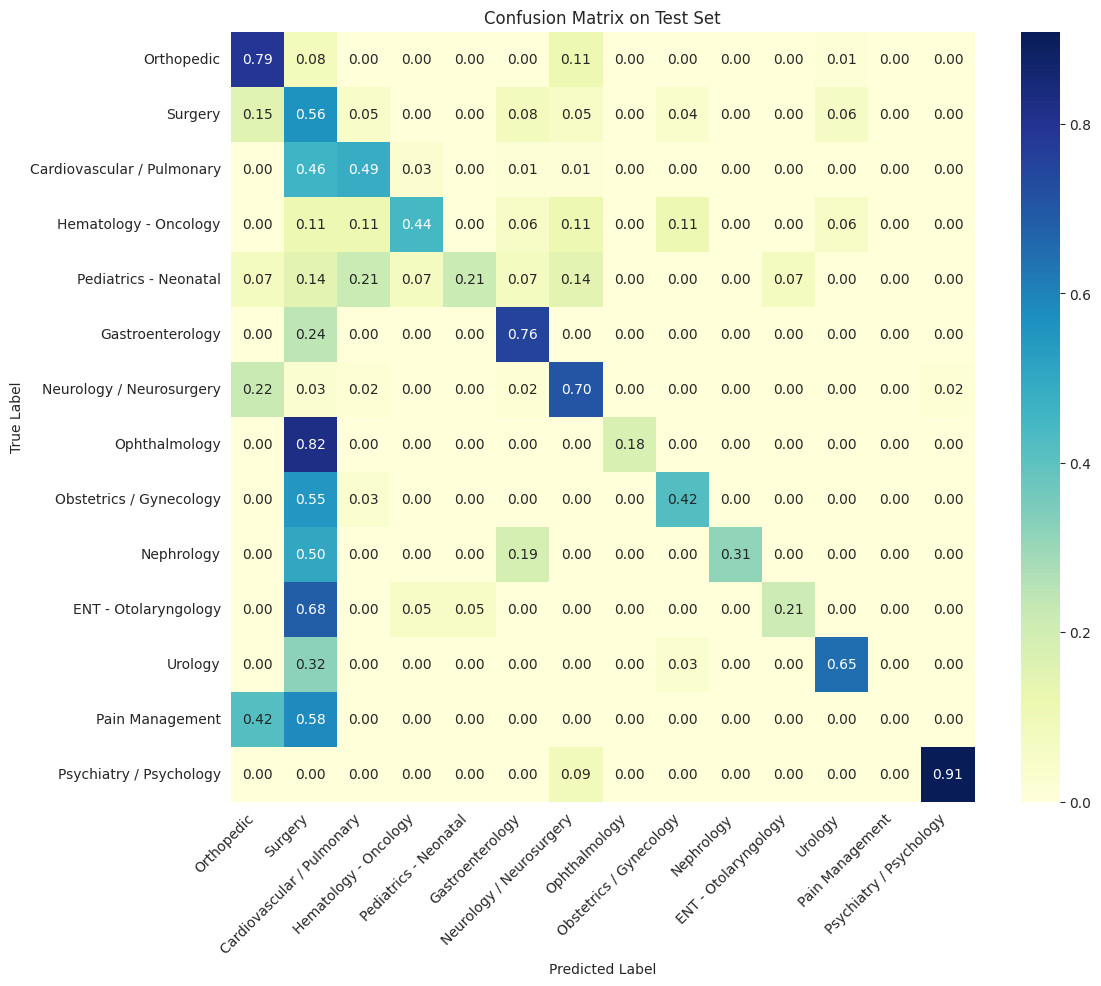


--- Evaluating Model 2 (Weighted) ---
--- Starting Test Set Evaluation ---
Running Inference on Test Set...


  0%|          | 0/41 [00:00<?, ?it/s]


CLASSIFICATION REPORT
Accuracy:          0.5323
Balanced Acc:      0.4870
F1 (Weighted):     0.4804
F1 (Macro):        0.4596  <-- Check for bias against small classes
MCC:               0.4185
Top-3 Accuracy:    0.9462
------------------------------
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.76      0.42      0.54        74
      ENT - Otolaryngology       0.52      0.58      0.55        19
          Gastroenterology       1.00      0.04      0.09        45
     Hematology - Oncology       0.72      0.72      0.72        18
                Nephrology       0.45      0.81      0.58        16
  Neurology / Neurosurgery       0.66      0.70      0.68        64
   Obstetrics / Gynecology       1.00      0.03      0.06        31
             Ophthalmology       0.61      0.65      0.63        17
                Orthopedic       0.75      0.13      0.22        71
           Pain Management       0.00      0.00      0.00        12

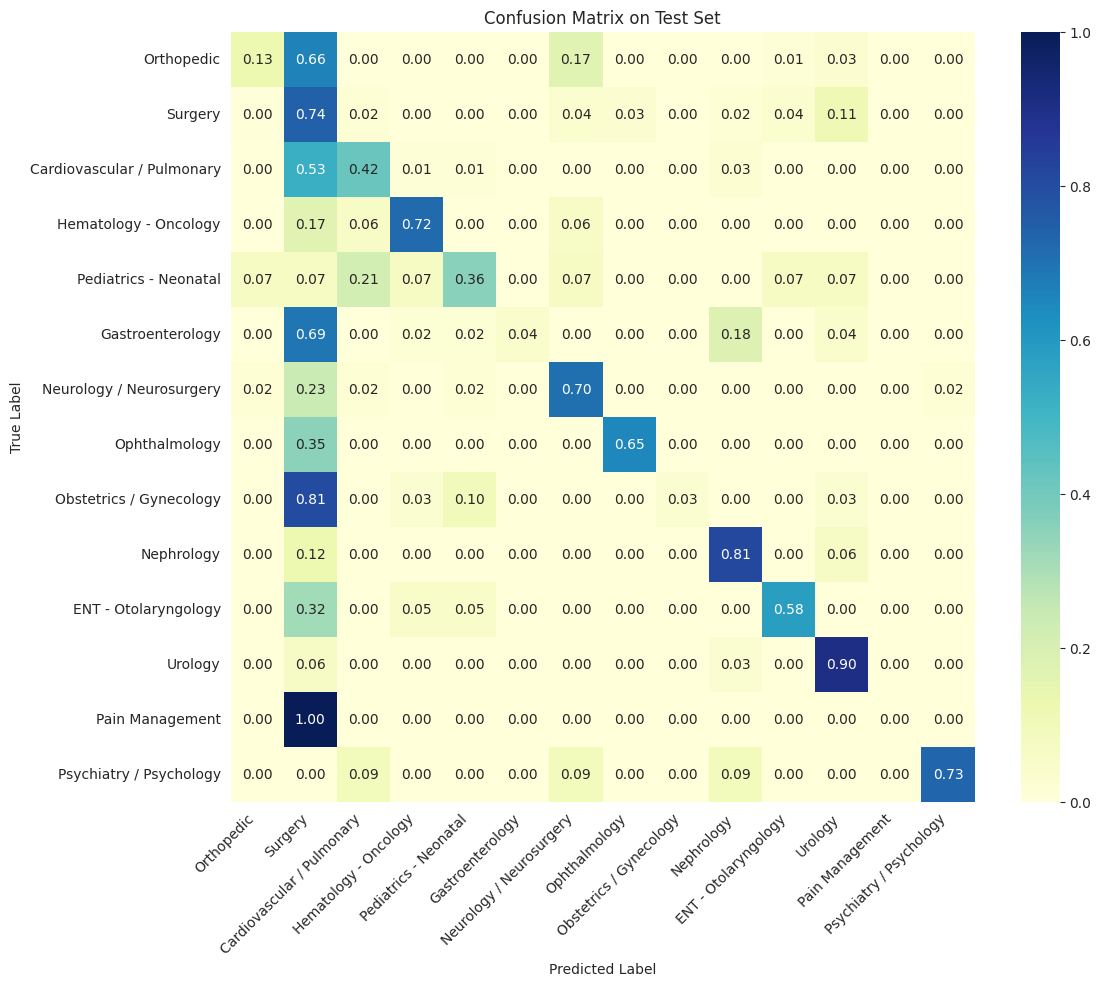


--- Evaluating Model 3 (Focal g=2) ---
--- Starting Test Set Evaluation ---
Running Inference on Test Set...


  0%|          | 0/41 [00:00<?, ?it/s]


CLASSIFICATION REPORT
Accuracy:          0.5508
Balanced Acc:      0.4877
F1 (Weighted):     0.5141
F1 (Macro):        0.4718  <-- Check for bias against small classes
MCC:               0.4431
Top-3 Accuracy:    0.9585
------------------------------
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.79      0.46      0.58        74
      ENT - Otolaryngology       0.50      0.74      0.60        19
          Gastroenterology       0.88      0.16      0.26        45
     Hematology - Oncology       0.70      0.78      0.74        18
                Nephrology       0.53      0.62      0.57        16
  Neurology / Neurosurgery       0.62      0.67      0.65        64
   Obstetrics / Gynecology       1.00      0.13      0.23        31
             Ophthalmology       0.64      0.82      0.72        17
                Orthopedic       0.79      0.21      0.33        71
           Pain Management       0.00      0.00      0.00        12

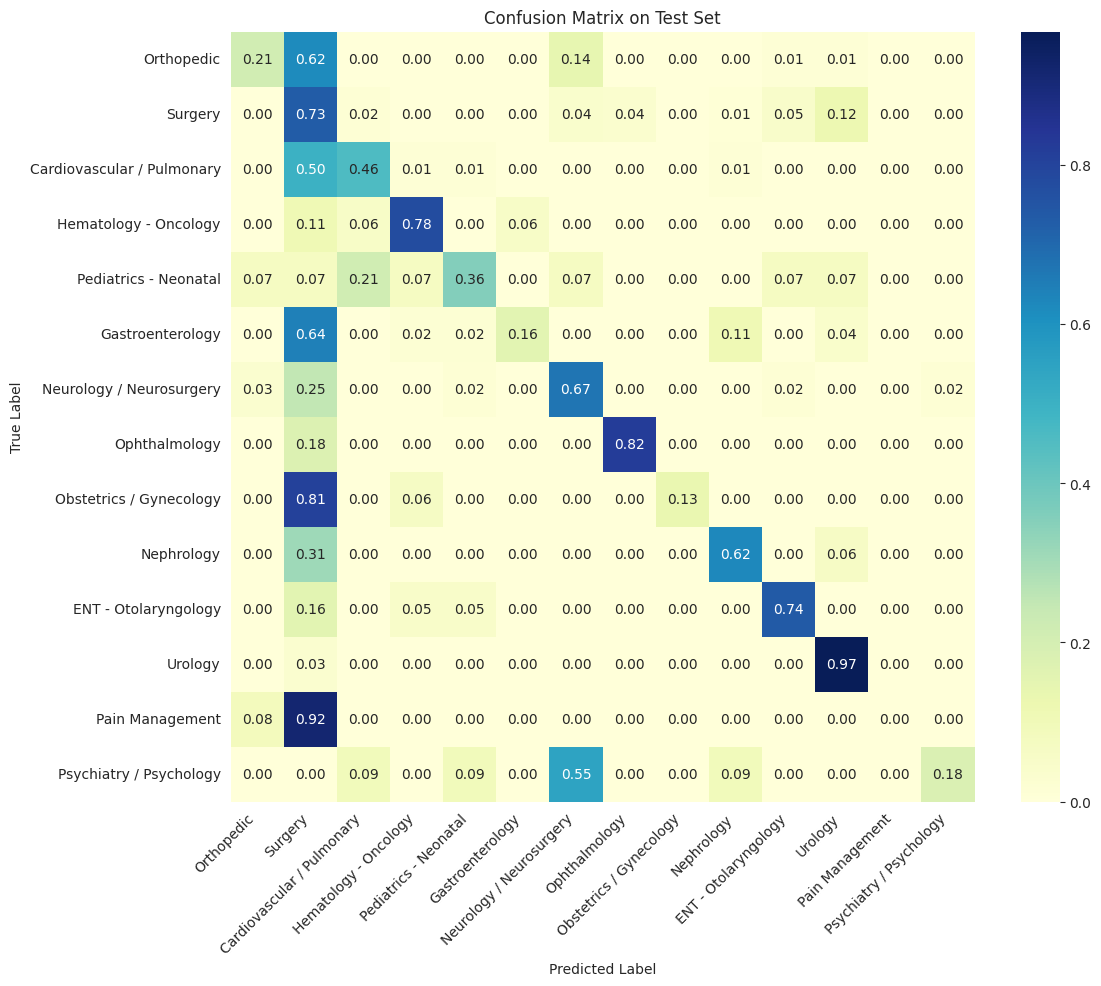


--- Evaluating Model 4 (Focal g=4) ---
--- Starting Test Set Evaluation ---
Running Inference on Test Set...


  0%|          | 0/41 [00:00<?, ?it/s]

In [ ]:
# Evaluation
results = {}

print('--- Evaluating Model 1 (Standard) ---')
results['Model 1 (Standard)'] = evaluate_test_set(trained_model_1, test_df, tokenizer, label_map)

print('\n--- Evaluating Model 2 (Weighted) ---')
results['Model 2 (Weighted)'] = evaluate_test_set(trained_model_2, test_df, tokenizer, label_map)

print('\n--- Evaluating Model 3 (Focal g=2) ---')
results['Model 3 (Focal g=2)'] = evaluate_test_set(trained_model_3, test_df, tokenizer, label_map)

print('\n--- Evaluating Model 4 (Focal g=4) ---')
results['Model 4 (Focal g=4)'] = evaluate_test_set(trained_model_4, test_df, tokenizer, label_map)


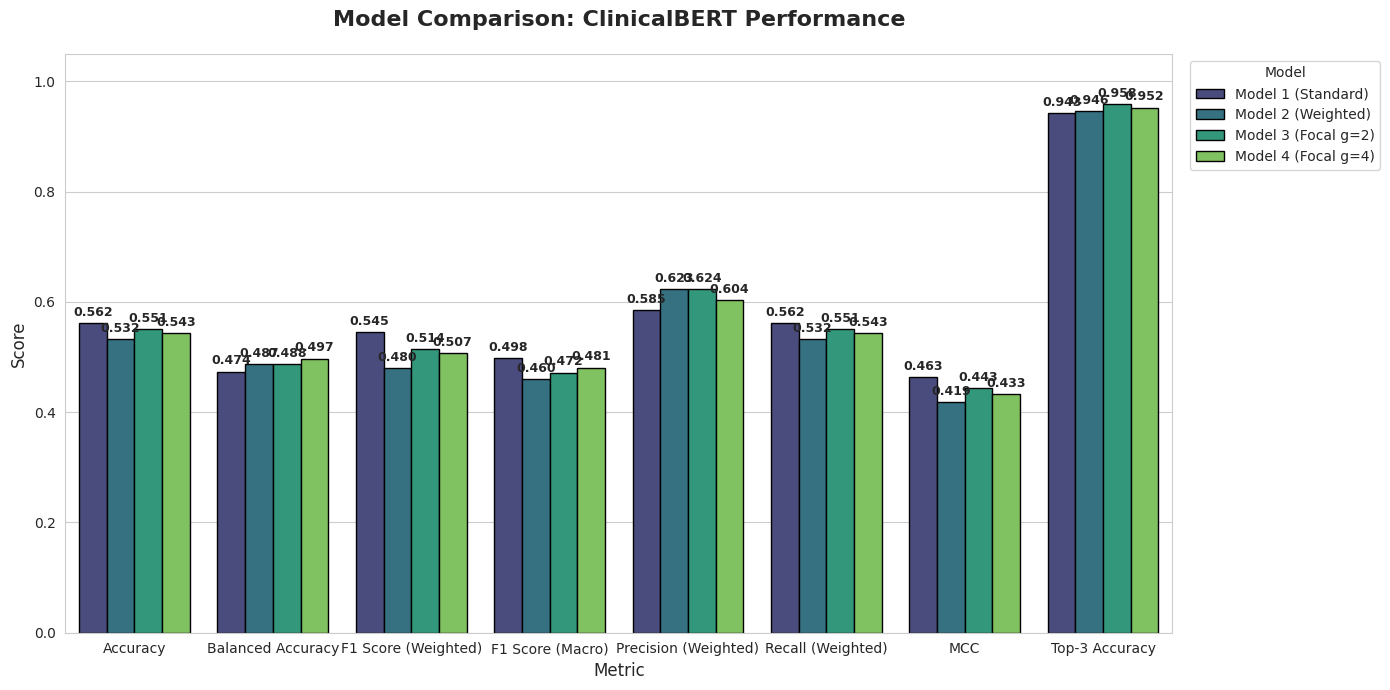

In [ ]:
# Generate Comparison Plot
plot_model_comparison(results)

### **E. Final Discussion**


% Results before initialized bias (10/12/2025)

To be honest, none of these models performed well. While Model 1 achieved the highest raw accuracy, it exhibited severe bias against minority classes (as we can see in the normalized confusion matrix). Model 2 leads to the best clinical outcome because it prioritizes sensitivity (Recall) for rare specialties, mitigating the risk of missing specialized diagnoses, even at the cost of confusing semantically overlapping fields like Gastroenterology and Surgery. The other two models, Model 3 and 4 give back the same results. This is probably because once the model down-weight easy examples significantly (which γ=2 already does), increasing it to 4 yields diminishing returns. It suggests that the difficulty in this dataset comes from semantic overlap (Gastroenterology and Surgery), not just "hard" examples.

Model 2 successfully "rescued" the minority classes but the key takeaway is that the dataset itself contain redundant examples that are different to catch, even with a correct methodology and a powerfull model like ClinicalBERT.


% Results after initialized bias function (with more metrics) (21/12/2025)


While Model 1 achieved the highest raw accuracy (56.1%), it exhibited severe bias against minority classes, making it clinically unsafe. Model 4 (Focal Loss γ=4) demonstrated the best balance, achieving the highest Balanced Accuracy (49.7%) and significantly improving recall for rare specialties like Urology (97%) and Ophthalmology (71%).

The consistent Top-3 Accuracy of ~95% across all models indicates that the primary bottleneck is not model capacity, but rather **label ambiguity** (semantic overlap between 'Surgery' and specific surgical sub-specialties). Future work should focus on hierarchy-based merging of labels rather than more complex architectures.
